# Plot Paralog Network Figures - Viz burden of GCEs detected per paralog network

# Import Statements (libraries + Functions)

In [1]:
import scipy.stats as stats


In [2]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [3]:
import ast

In [4]:
import screed
import mmh3

In [5]:
from Bio import SeqIO


In [6]:
import json

In [7]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [8]:
import subprocess

In [9]:
from pycirclize import Circos


In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [11]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

# Function to convert base pairs to kilobases

def bp_to_kb(x, pos):
    return f'{x * 1e-3:.0f}'

# Example usage
# axs[0].xaxis.set_major_formatter(FuncFormatter(bp_to_kb))
# axs[0].set_xlabel("Distance (kb)")


In [12]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [13]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [14]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [15]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, compute_Paralog_EdgeToEdge_Distance

from gcutils.general import gini_coefficient_FromPDSeries

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

# from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, label_HmMap_Variants_DF_ByOvrLapGenes

from gcutils.homologymap_graph import CreatePR_DiGraph, CreatePR_UGraph, summarize_graph_stats, subset_graph_by_PR_SetIDs



### Import functions for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [16]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from gcutils.genomeviz_utils import plot_Anno_WiVariantCalls_2Panel, plot_Anno_with_empty_bottom

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3

from gcutils.genomeviz_utils import plot_variants_for_isolates_simple
from gcutils.genomeviz_utils import plot_paralog_variants_on_ax
from gcutils.genomeviz_utils import plot_genome_annotation_on_ax

from gcutils.genomeviz_utils import overlay_gc_event_highlights_on_variants

from gcutils.genomeviz_utils import viz_region_Tree_Variants_Anno_ParalogVariants, viz_region_Tree_Variants_Anno


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions related to phylogeny/tree viz

In [17]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
from gcutils.gubbinsfuncs import get_BranchLengths_and_DescendantCounts_FromTree

from gcutils.gubbinsfuncs import annotate_tree_with_lineages, infer_InternalNode_Lineages


from gcutils.treeviz_mpl import mpl_plot_tree

from gcutils.treeviz_ete_utils import subset_tree_by_leaf_ids, subset_ETE_Tree
from gcutils.treeviz_ete_utils import style_ETE3_Tree_ByMtbLineage_V1

from gcutils.treeviz_ete_utils import style_single_node_in_tree
from gcutils.treeviz_ete_utils import subset_ETE_Tree_Style_GCEChildNode 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Functions

In [18]:
import re
import pandas as pd
import numpy as np

# reuse your existing regex
CS_OP_RE = re.compile(r'([:=*+-])(\d+|[A-Za-z]+)')

def count_substitutions_in_cs(cs: str) -> int:
    """
    Count the number of substitution events (*xy) in a minimap2 cs tag.

    Parameters
    ----------
    cs : str
        A single cs tag string (e.g. ':6-ata:10+gtc:4*at:3').

    Returns
    -------
    int
        Number of substitutions detected in this cs string.
    """
    if cs is None or (isinstance(cs, float) and pd.isna(cs)):
        return 0

    n_sub = 0
    for op, arg in CS_OP_RE.findall(cs):
        if op == '*':
            # arg is two bases: ref, query
            ref_base = arg[0]
            alt_base = arg[1]
            # mirror your variant logic: skip ambiguous Ns
            if ref_base.lower() != "n" and alt_base.lower() != "n":
                n_sub += 1

    return n_sub


In [19]:

def calculate_gc_content_perwindow(genome_seq, df,
                                   start_col = "Target_Start",
                                   end_col   = "Target_End"):
    """
    Compute GC content for each genomic window in the DataFrame.
    
    Parameters:
    - genome (str): The full genome sequence as a string.
    - df (pd.DataFrame): DataFrame containing "Target_Start" and "Target_End" columns.
    
    Returns:
    - pd.DataFrame: Updated DataFrame with a new column "GC_Content".
    """
    gc_contents = []
    
    for _, row in df.iterrows():
        start = int(row[start_col]) - 1  # Convert to 0-based indexing
        end = int(row[end_col])
        
        # Extract sequence from genome string
        subseq = genome_seq[start:end]
        
        # Calculate GC content
        gc_count = subseq.count('G') + subseq.count('C')
        total_bases = len(subseq)
        gc_content = (gc_count / total_bases) * 100 if total_bases > 0 else None
        
        gc_contents.append(gc_content)

    # Add results to DataFrame
    df["GC_Content"] = gc_contents
    df["GC_Content"] = df["GC_Content"].astype(float)

    return df



In [20]:
def gene_categories_from_symbols(
    gene_str,
    symbol_to_cat,
    sep=",",
    unknown_label="unknown",
    return_type="list",   # "list" or "set" or "csv"
):
    """
    Map a comma-separated gene string to gene categories.

    Args:
        gene_str (str): e.g. "PPE18, PPE19"
        symbol_to_cat (dict): Symbol -> Gene_Cat mapping
        sep (str): separator for gene symbols
        unknown_label (str or None): label for unmapped genes
        return_type (str): "list", "set", or "csv"

    Returns:
        list / set / str of gene categories
    """
    if gene_str is None or not isinstance(gene_str, str) or gene_str.strip() == "":
        return [] if return_type != "csv" else ""

    cats = set()

    for g in gene_str.split(sep):
        g = g.strip()
        if not g:
            continue

        cat = symbol_to_cat.get(g)
        if cat is None:
            if unknown_label is not None:
                cats.add(unknown_label)
        else:
            cats.add(cat)

    if return_type == "set":
        return cats
    elif return_type == "csv":
        return ", ".join(sorted(cats))
    else:
        return sorted(cats)

In [21]:
def add_gene_category_column(
    df,
    gene_col,
    symbol_to_cat,
    new_col="Gene_Categories",
    sep=",",
    unknown_label="unknown",
    return_type="list",
):
    """
    Add a column listing gene categories observed per row.

    Args:
        df (DataFrame)
        gene_col (str): column containing gene symbols (comma-separated)
        symbol_to_cat (dict): Symbol -> Gene_Cat mapping
        new_col (str): name of new column
        return_type (str): "list", "set", or "csv"

    Returns:
        DataFrame (copy)
    """
    out = df.copy()
    out[new_col] = out[gene_col].apply(
        lambda x: gene_categories_from_symbols(
            x,
            symbol_to_cat=symbol_to_cat,
            sep=sep,
            unknown_label=unknown_label,
            return_type=return_type,
        )
    )
    return out


# ETE3 Settings & Parameters Setup

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [22]:

import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [23]:
Mtb_LinToColor_Dict = {"lineage1": "#DF83AC",
                      "lineage2": "#7098CB",
                      "lineage3": "#815D9F",
                      "lineage4": "#E76956",
                      "lineage5": "#B67548",
                      "lineage6": "#6AB79E",
                      "lineage8": "#E4515B", 
                      "None": "black",}


In [24]:

ts_vt_NoScale = ETE.TreeStyle()
ts_vt_NoScale.show_leaf_name = False
ts_vt_NoScale.show_branch_length = False
ts_vt_NoScale.show_branch_support = False
ts_vt_NoScale.show_scale = False #True
ts_vt_NoScale.branch_vertical_margin = 2
ts_vt_NoScale.rotation = 90

ts_hz_NoScale = ETE.TreeStyle()
ts_hz_NoScale.show_leaf_name = False
ts_hz_NoScale.show_branch_length = False
ts_hz_NoScale.show_branch_support = False
ts_hz_NoScale.show_scale = False #True
ts_hz_NoScale.branch_vertical_margin = 2
ts_hz_NoScale.rotation = 0

ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
#ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = False #True
ts_ColLin_circ.branch_vertical_margin = 2
#ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout

ts_ColLin_FullCirc = ETE.TreeStyle()
ts_ColLin_FullCirc.mode = "c" # draw tree in circular mode
ts_ColLin_FullCirc.arc_start = -90 #-180 # 0 degrees = 3 o'clock
ts_ColLin_FullCirc.arc_span = 355
ts_ColLin_FullCirc.show_leaf_name = False
ts_ColLin_FullCirc.show_branch_length = False
ts_ColLin_FullCirc.show_branch_support = False
ts_ColLin_FullCirc.show_scale = False #True
ts_ColLin_FullCirc.branch_vertical_margin = 2
# ts_ColLin_FullCirc.rotation = 90


# Define Color Pallete `Mtb-H37Rv` Gene Categories 

In [25]:
all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx", "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

NQ_Colors = ['065275', '029099', '7CCBA1', 'FDDE9C', 'F0746E', 'DC3978', '7C1E6F']


Mtb_GeneCat_ColorDict = { 
    "PE/PPE" : "#57A89D", #"#1ABFAD", 
    "REP13E12_Repeat" : "#D3516D", 
    "esx" : "#5D81AA", 
    "lipid metabolism" : "#6EA4D4",  # Warm brownish-orange
    "conserved hypotheticals" : "#F2B84A", 
    "cell wall and cell processes" : "#7D3E84", 
    "insertion seqs and phages": "#E16843", 
    "intermediary metabolism and respiration" : "#4F7942",  # Deep green
    "information pathways": "#5698C4",  # Soft blue
    "virulence, detoxification, adaptation": "#B0338E",  # Magenta-purple
    "regulatory proteins": "#A42CD6",  # Vivid violet
    "stable RNAs": "#5C5C5C",  # Neutral dark gray
    "unknown": "#999999",  # Lighter gray for unknown
}

Mtb_GeneCat_ColorPallete =  [Mtb_GeneCat_ColorDict[cat] for cat in all_categories] 

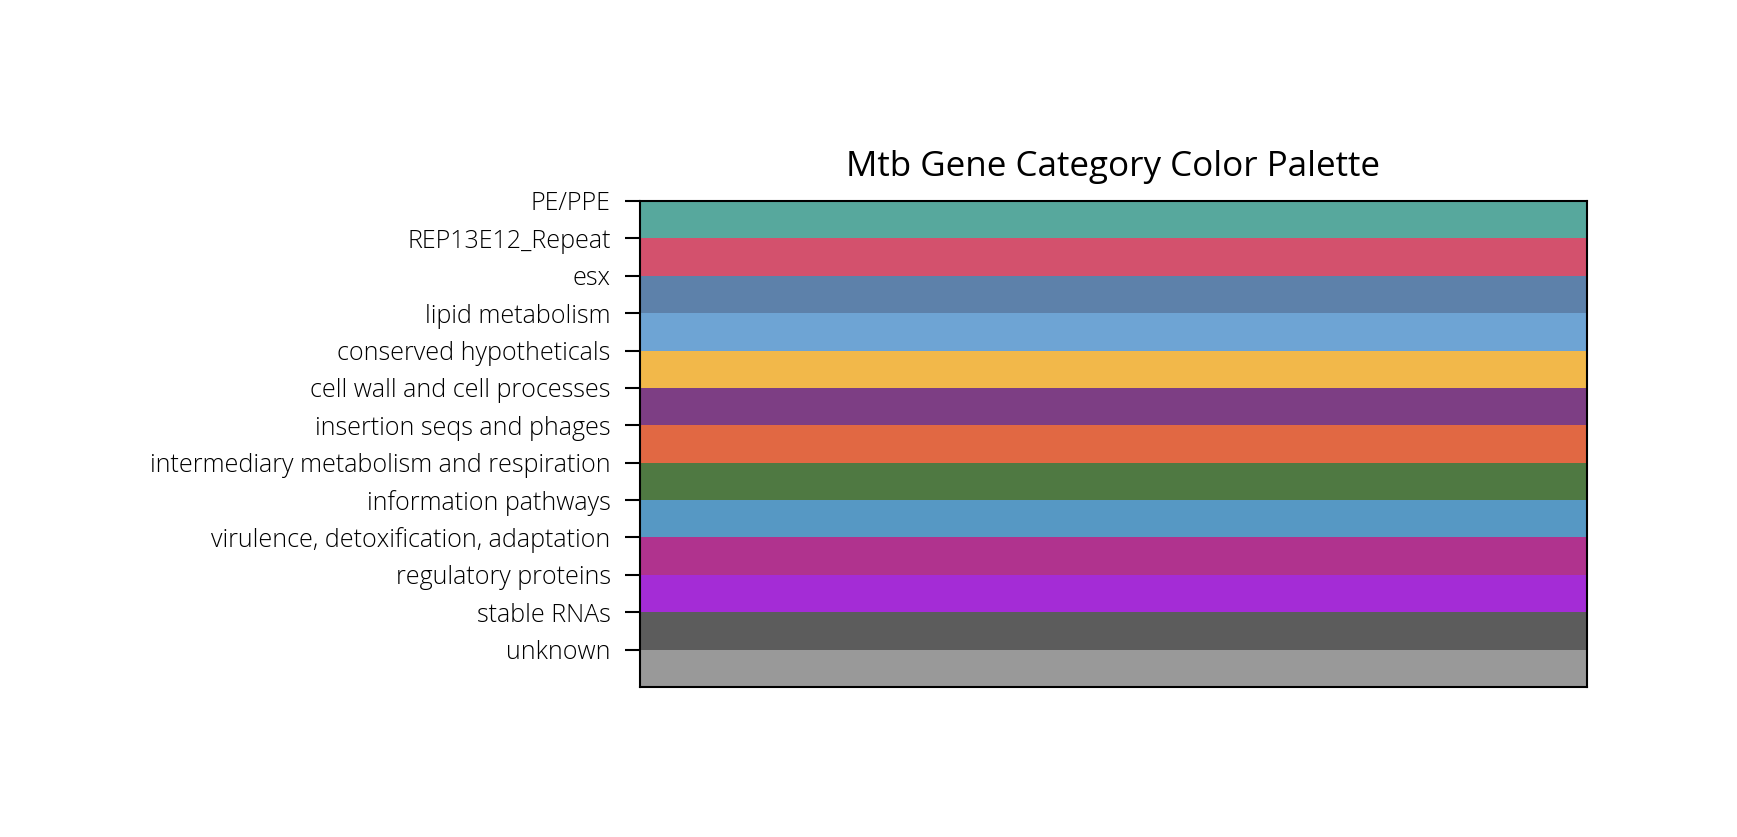

In [26]:
# Plot the colors
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(Mtb_GeneCat_ColorDict))
ax.set_xticks([])
ax.set_yticks(range(len(Mtb_GeneCat_ColorDict)))
ax.set_yticklabels(Mtb_GeneCat_ColorDict.keys(), fontsize=6)

for i, (category, color) in enumerate(Mtb_GeneCat_ColorDict.items()):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

plt.gca().invert_yaxis()
plt.title("Mtb Gene Category Color Palette")
plt.show()

# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [27]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [28]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [29]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [30]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)
Mtb_H37rv_Graphic_Record.feature_level_height = 0

1


# Parse `Mtb151CI` Isolate Metadata

In [31]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [32]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [33]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [34]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Parse all individual variants per genome annotated by CDS effect (`WGA-151CI`)

In [35]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1/"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [36]:

Mtb151CI_AllAsm_AllVar_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

# WGA151_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF.shape

(260869, 20)

In [37]:
AllAsm_AllVar_DF["SampleID"].nunique()

151

# Parse HHRs tested for Enrichment of "Paralog-Matching" SNPs

In [38]:
HHR_TestForParalogSNPs_TSV = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_HHR_MutAttributes_V3/HHR.TestedForParalogSNPS.V1.tsv"

HHR_SNP_Sig_DF  = pd.read_csv(HHR_TestForParalogSNPs_TSV,
                              sep = "\t")

HHR_SNP_Sig_DF["Num_Overlap_Genes"] = HHR_SNP_Sig_DF["Overlap_Genes"].str.split(",").apply(len)

HHR_SNP_Sig_DF.shape

(61, 31)

In [39]:
HHR_SNP_Sig_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Num_Overlap_Genes
0,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,7329,1,17,4,0.0,500.0,500.0,0.002320,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.997680,0.018605,3
1,25,NC_000962.3,606510,608060,607285.0,1550,"Rv0515,Rv0516c",0,1,1,0,25,PR_HmRegion_025,0,4650,1,10,3,0.0,500.0,500.0,0.002151,1.000000e-40,500.0,0,1395.000000,3.144574,10.446049,2.997849,0.013953,2
2,44,NC_000962.3,1169296,1170733,1170014.5,1437,Rv1047,1,5,3,0,44,PR_HmRegion_044,0,4311,2,34,16,0.0,500.0,500.0,0.015774,1.000000e-40,500.0,0,1014.352941,3.006189,9.986344,15.984226,0.074419,1
3,15,NC_000962.3,400151,401701,400926.0,1550,Rv0336,0,1,1,0,15,PR_HmRegion_015,0,4650,1,14,3,0.0,500.0,500.0,0.003011,1.000000e-40,500.0,0,996.428571,2.998446,9.960623,2.996989,0.013953,1
4,158,NC_000962.3,3481324,3482760,3482042.0,1436,Rv3115,1,5,3,0,158,PR_HmRegion_158,0,4308,2,64,29,0.0,500.0,500.0,0.029712,1.000000e-40,500.0,0,976.031250,2.989464,9.930784,28.970288,0.134884,1


# Import/parse processed H37rv genome annotations

In [40]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
# H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

Symbol_To_Rv_GeneCat_V2_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Gene_Cat_V2']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [41]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [42]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [43]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [44]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [45]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [46]:
from Bio import SeqIO


In [47]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [48]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [49]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [50]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 141080.35it/s]


### Parse MycoBrowser Gene Seq Ref

In [51]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 77006.78it/s]


In [52]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [53]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 20914.48it/s]


In [54]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [55]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [56]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [57]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [58]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [59]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [60]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [61]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [62]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [63]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [64]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [65]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [66]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [67]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [68]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [69]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [70]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [71]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [72]:
Mtb_HM_Var_PR_SNPs_DF.head(5)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [73]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [74]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"


### Parse pickle of NucDiv stats

In [75]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [76]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [77]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")

NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv'] - median_1kb_PI))


### Define NucDiv Hospots (N = 37)

In [78]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

In [79]:
NucDiv_HSR_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1


#### Extra Inspection of NucDiv DFs

In [80]:
NucDiv_1kb_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0


In [81]:
NucDiv_1kb_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [82]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1


In [83]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 20)

In [84]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 20)

# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [85]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV


HmPairs_GCE_Info_WiModPN10_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.ModPN10.tsv"
HmRegions_GCE_Info_WiModPN10_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.ModPN10.tsv"  

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_WiModPN10_TSV"] = HmRegions_GCE_Info_WiModPN10_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_WiModPN10_TSV"]       = HmPairs_GCE_Info_WiModPN10_TSV 


# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## A) Parse table of ALL Gubbins Events (all putative recomb events) - `WGA-151-GCE` 

In [86]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [87]:
# Parse annotated events TSV
GRE_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GRE_DF['taxa_List'] = GRE_DF['taxa_List'].apply(ast.literal_eval)
GRE_DF["LenOfTaxaList"] = GRE_DF["taxa_List"].apply(len)

GRE_DF.shape

(324, 31)

### B) Parse Gubbins recombination events counted over regions (`1 kb window`, `Gene-level`, `HmRegion`)

In [88]:
GCE_CtPerGene_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")

GCE_CtPerGene_Atleast1_DF = GCE_CtPerGene_DF.query("pGCE_Count > 0")
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [89]:
GRE_PerPRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"] , sep = "\t")
GRE_PerPRStats_DF.shape

(200, 18)

## C) Parse Gubbins Events - branch-level stats

In [90]:
G_BranchStats_Filt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
G_BranchStats_Filt_DF.shape

(300, 15)

In [91]:
G_BranchStats_Filt_DF.head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,N0072,328,36,292,4,391,3619,0.123288,0.013699,4411487,4408943,lineage1,295.04892,0.0,328


In [92]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
215,Node_65,208,16,192,2,946,1898,0.083333,0.010417,4411532,4409993,lineage4,199.414017,62.0,208


## D) Read in the "node_To_PrimaryLin_Dict" dictionary 

In [93]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

## E) Gubbins ASR SNP DFs

In [94]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [95]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [96]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [97]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

### Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [98]:
Gub_SNPs_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"],
                                         sep = "\t")
Gub_SNPs_V2_DF.shape

(26508, 23)

In [99]:
#Gub_SNPs_V2_DF.head(1)

In [100]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [101]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [102]:
GRE_AnnoByMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")


# Convert the string column to a list of strings
GRE_AnnoByMatch_DF['taxa_List']     = GRE_AnnoByMatch_DF['taxa_List'].apply(ast.literal_eval)
GRE_AnnoByMatch_DF["LenOfTaxaList"] = GRE_AnnoByMatch_DF["taxa_List"].apply(len)


##### Label GC Events by overlap w/ NucDiv Hotspots ######
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")

print(GRE_AnnoByMatch_DF.shape)
GRE_AnnoByMatch_DF = bf.count_overlaps(GRE_AnnoByMatch_DF, NucDiv_HSR_1kb_DF, 
                               cols1 = RE_CoordCols,
                               cols2 = GenomeAnno_CoordCols).rename(columns={'count': 'N_NucDivHotSpots'})
print(GRE_AnnoByMatch_DF.shape)

##########################################################

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)
(324, 47)


(324, 47)

### F.2) Event to all paralogs DF

In [103]:
GCE_MatchToEachPR_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GCE_MatchToEachPR_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [104]:
with open(i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


### F.4) HmMap and GCE Stats annotated onto HmRegions and HmMap alignment pairs  
- Parse in mapping results quantified across `Paralogous Regions and each `HmMap-Alignment`

In [105]:
HmPair_EventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"],
                                sep = "\t")

HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)


HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")
HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")



HmRegions_DonorAndEventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"],
                                           sep = "\t")


In [106]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [107]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


## G) Parsimony Scoring of SNPs per GC Event


In [108]:
GCE_FitchQC_PerEvent_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"],
                                      sep = "\t")

GCE_FitchQC_PerSite_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"],
                                      sep = "\t")

print("Parsimony Scores - per GC Event - DF shape:", GCE_FitchQC_PerEvent_DF.shape)
print("Parsimony Scores - per SNP of each GC Event - DF shape:", GCE_FitchQC_PerSite_DF.shape)


Parsimony Scores - per GC Event - DF shape: (324, 11)
Parsimony Scores - per SNP of each GC Event - DF shape: (2916, 10)


## J) Parse GCE Mapping Per PR and ParalogNetwork - W/ Mod PN10

In [109]:

HmPair_EventCt_ModPN10_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_WiModPN10_TSV"],
                                 sep = "\t")


HmRegions_DonorAndEventCt_ModPN10_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_WiModPN10_TSV"],
                                                 sep = "\t")


In [110]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [111]:
HmRegions_DonorAndEventCt_ModPN10_DF.shape

(202, 24)

In [112]:
HmPair_EventCt_DF["SeqID"].describe()

count    640.000000
mean       0.909251
std        0.113476
min        0.599430
25%        0.817760
50%        0.982940
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

In [113]:
HmPair_EventCt_ModPN10_DF["SeqID"].describe()

count    642.000000
mean       0.908593
std        0.113909
min        0.599430
25%        0.817116
50%        0.982036
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

In [114]:
HmPair_EventCt_ModPN10_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


# Process Gubbins Tree (`Mtb-151CI`)

## Parse and annotate phylogeny

In [115]:
## 1) Parse Gubbins Tree w/ ETE3

i_Gubbins_T = Tree(i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"],
                   format = 1)

# Root the Mtb-151CI tree on the L8 isolate
i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_T_RootPoint)

## 2) Parsing over each node of the tree (ETE3), get ML BRANCH LENGTH and Number of descendents per node
Tree_BranchLen_Dict, Tree_NumDescendants_PerNode_Dict = get_BranchLengths_and_DescendantCounts_FromTree(i_Gubbins_T)

## 3) Label each LEAF within phylogeny by MTBC Lineage + Infer lineage of each internal node of the tree
i_Gubbins_T = annotate_tree_with_lineages(i_Gubbins_T,
                                          SampleID_To_PrimLineage_Dict)

# i_Gubbins_T, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T,
#                                                                         SampleID_To_PrimLineage_Dict)

                          

Number of leaves processed: 151


In [116]:
MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


# Viz `Mtb-151CI` phylogeny with branches colored by MTBC Lineage

In [117]:
Mtb_151CI_Tree_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


### Viz `Mtb151CI` Tree -  w/ ETE3

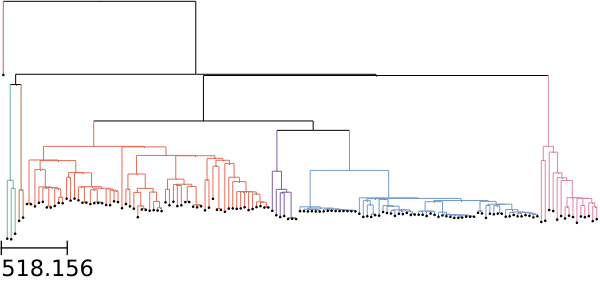

In [118]:
in_Tree = Mtb_151CI_Tree_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

In [119]:
# in_Tree = Mtb_151CI_Tree_V1.copy()
# in_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_circ)

In [120]:
# in_Tree = Mtb_151CI_Tree_V1.copy()
# in_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_FullCirc)

### Viz `Mtb151CI` Tree - `Custom Matplotlib tree viz Function`

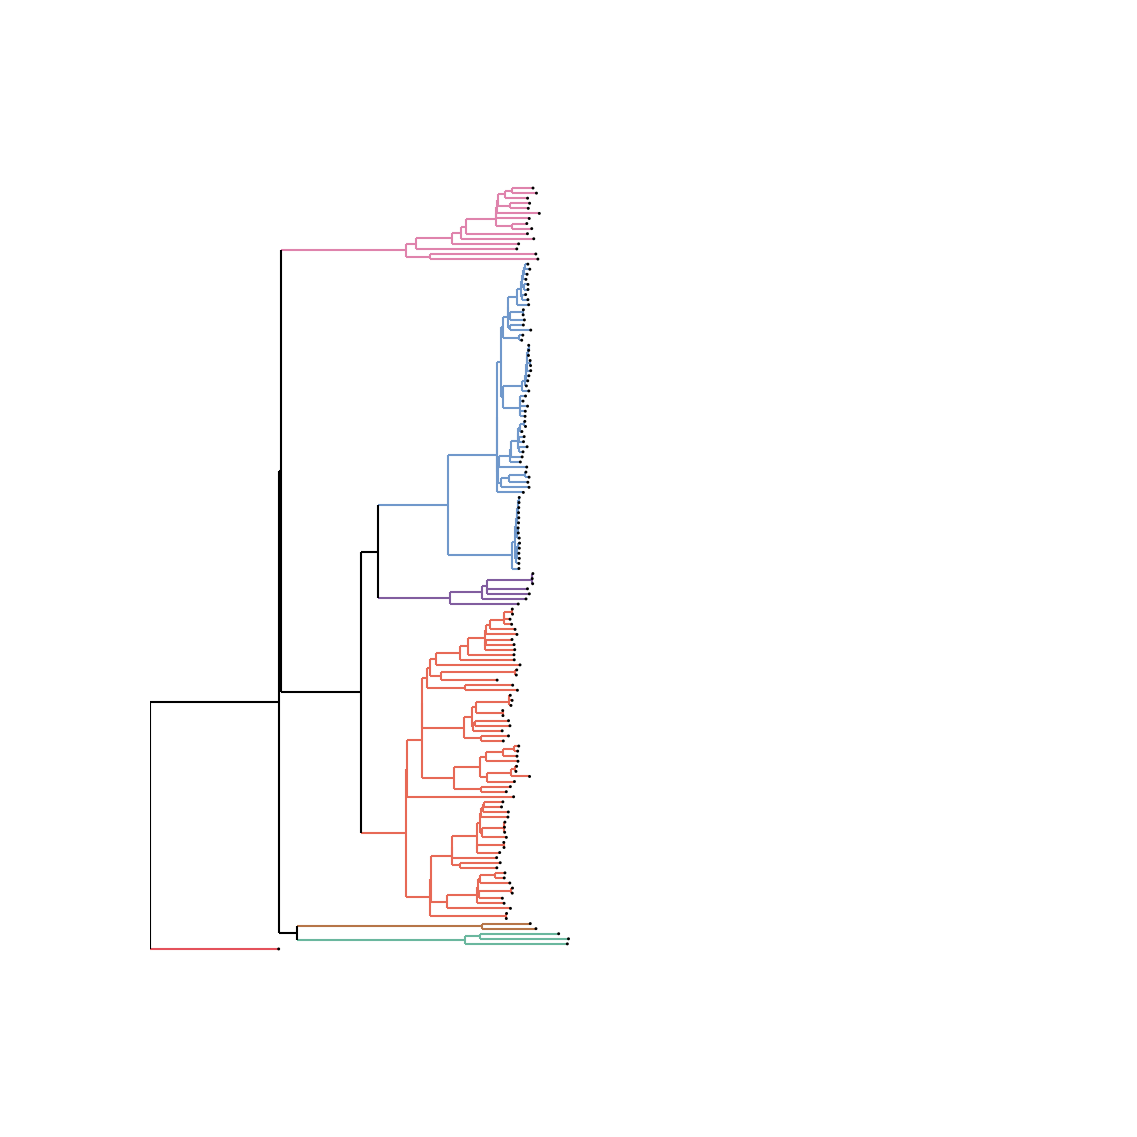

In [121]:
fig, ax_1 = plt.subplots(figsize=(3, 3))

### 1) Plot tree on ax1 axis
coords, NameToCoords = mpl_plot_tree(Mtb_151CI_Tree_V1,
                                     name_offset=0.7,
                                     axe=ax_1,
                                     show_names=False,
                                     draw_leaf_nodes=True,
                                     leaf_node_size=1.0,
                                     pad_right=1,
                                     show_scale_bar = False,
                                     )

#fig

# Classify & Divide sets of GC Events based on Paralog Mapping results

In [122]:
GCE_All_DF = GRE_AnnoByMatch_DF
GCE_ABM_DF = GRE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GRE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm >= 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GRE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm < 0.5")

GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])
#print("# of NOT MAPPED events NOT IN a Paralog-Region:", GCE_NotMapped_NotInPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


# Part Y

### Inspect the 

In [123]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [124]:
HmRegions_DonorAndEventCt_ModPN10_DF.shape

(202, 24)

In [125]:
HmPair_EventCt_ModPN10_DF.head(4)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.000000,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.000000,0,374,181.729835,1,1609866.0,1609.8660,65.328110
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3,8.0,"(600000, 650000]",625000.0,"Rv0094c,Rv0095c","Rv3466,Rv3467",0.421053,17,35,25.179856,2,631701.5,631.7015,67.123288
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3,2.5,"(1650000, 1700000]",1675000.0,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",0.131579,10,33,24.372230,2,1684734.5,1684.7345,67.036216


In [126]:
HmRegions_DonorAndEventCt_ModPN10_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.000000,0.000000,20,20
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0.0,0,0,0.0,0.0,0.000000,0.000000,374,374
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4,0.0,0,0,0.0,0.0,0.000000,0.000000,38,38


### FIlter down Paralog Pair info V2 - OG

In [127]:
print("PR Pairs w/ TOTAL:", HmPair_EventCt_DF.shape)

HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 1.0")
print("PR Pairs w/ NON-PERFECT match:", HmPair_EventCt_NoPerf_DF.shape)

HmPair_EventCt_NoPerf_Filt_DF = HmPair_EventCt_NoPerf_DF.query(" Query_HmRegionID != 'PR_HmRegion_140' & Query_NOvrlap_Transposase == 0  ")

print("PR Pairs w/ NON-PERFECT match + Filtered:", HmPair_EventCt_NoPerf_Filt_DF.shape)


PR Pairs w/ TOTAL: (640, 51)
PR Pairs w/ NON-PERFECT match: (385, 51)
PR Pairs w/ NON-PERFECT match + Filtered: (284, 51)


In [128]:
print(  HmPair_EventCt_NoPerf_DF["Target_HmRegionNum"].nunique() )
print(  HmPair_EventCt_NoPerf_DF["Query_HmRegionNum"].nunique() )

179
179


In [129]:
print(  HmPair_EventCt_NoPerf_Filt_DF["Target_HmRegionNum"].nunique() )
print(  HmPair_EventCt_NoPerf_Filt_DF["Query_HmRegionNum"].nunique() )

148
148


In [130]:
HmPair_EventCt_ModPN10_DF.head(4)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.000000,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.000000,0,374,181.729835,1,1609866.0,1609.8660,65.328110
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3,8.0,"(600000, 650000]",625000.0,"Rv0094c,Rv0095c","Rv3466,Rv3467",0.421053,17,35,25.179856,2,631701.5,631.7015,67.123288
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3,2.5,"(1650000, 1700000]",1675000.0,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",0.131579,10,33,24.372230,2,1684734.5,1684.7345,67.036216


In [131]:
HmPair_EventCt_ModPN10_DF.head(1)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295


### FIlter down Paralog Pair info V2 - NEW w/ MOD PN10

In [132]:
print("PR Pairs w/ TOTAL:", HmPair_EventCt_ModPN10_DF.shape)

HmPair_EventCt_ModPN10_NoPerf_DF = HmPair_EventCt_ModPN10_DF.query("SeqID < 1.0")
print("PR Pairs w/ NON-PERFECT match:", HmPair_EventCt_ModPN10_NoPerf_DF.shape)

HmPair_EventCt_ModPN10_NoPerf_Filt_DF = HmPair_EventCt_ModPN10_DF.query(" Query_HmRegionID != 'PR_HmRegion_140' & Query_NOvrlap_Transposase == 0  ")

print("PR Pairs w/ NON-PERFECT match + Filtered:", HmPair_EventCt_ModPN10_NoPerf_Filt_DF.shape)


PR Pairs w/ TOTAL: (642, 51)
PR Pairs w/ NON-PERFECT match: (387, 51)
PR Pairs w/ NON-PERFECT match + Filtered: (311, 51)


In [133]:
print(  HmPair_EventCt_ModPN10_NoPerf_DF["Target_HmRegionNum"].nunique() )
print(  HmPair_EventCt_ModPN10_NoPerf_DF["Query_HmRegionNum"].nunique() )

181
181


In [134]:
print(  HmPair_EventCt_ModPN10_NoPerf_Filt_DF["Target_HmRegionNum"].nunique() )
print(  HmPair_EventCt_ModPN10_NoPerf_Filt_DF["Query_HmRegionNum"].nunique() )

164
164


In [135]:
PR_HmRegIDs_NoPerfRepeat_Filt_List = list(HmPair_EventCt_NoPerf_Filt_DF["Query_Cluster"].unique())

# Part X

| Rank | Paralog Set | Putative GCEs | Mapped GCEs | # Regions | # Genes | Paralogous Regions (with genes) |
|------|--------------|----------------|--------------|-----------|----------|----------------------------------|
| 1 | **PR_Set_3** | 58 | 35 | 3 | 6 | PR_HmRegion_002 (Rv0094c, Rv0095c); PR_HmRegion_074 (Rv1587c, Rv1588c); PR_HmRegion_180 (Rv3466, Rv3467) |
| 2 | **PR_Set_23** | 40 | 32 | 4 | 6 | PR_HmRegion_031 (PE_PGRS9); PR_HmRegion_064 (PE_PGRS27); PR_HmRegion_065 (PE_PGRS28, Rv1453); PR_HmRegion_117 (Rv2370c, PE_PGRS40) |
| 3 | **PR_Set_10_A** | 33 | 12 | 7 | 11 | PR_HmRegion_010 (PE_PGRS4); PR_HmRegion_037 (PE_PGRS12, PE_PGRS13); PR_HmRegion_059 (PE_PGRS24); PR_HmRegion_176 (PE_PGRS52); PR_HmRegion_183 (PE_PGRS54); PR_HmRegion_184 (PE_PGRS55, PE_PGRS56, fadD18); PR_HmRegion_185 (PE_PGRS57, fadD19) |
| 4 | **PR_Set_28** | 26 | 23 | 5 | 12 | PR_HmRegion_042 (esxI, esxJ); PR_HmRegion_054 (PPE18, esxK, esxL); PR_HmRegion_087 (esxM, esxN); PR_HmRegion_113 (esxO, esxP, Rv2348c); PR_HmRegion_189 (esxV, esxW) |
| 5 | **PR_Set_36** | 20 | 20 | 3 | 5 | PR_HmRegion_053 (PE13, PPE18); PR_HmRegion_060 (PPE19); PR_HmRegion_182 (PE31, PPE60) |


In [136]:
import pandas as pd

def build_all_prset_details_tables(
    df,
    pr_col="PR_SetID",
    region_col="HmRegionID",
    genes_col="Overlap_Genes",
    put_col="N_Events_Putative",
    map_col="N_Events_Mapped",
    drop_na_pr=True,
):
    """
    Build summary tables for ALL PR_SetIDs (paralog networks).

    Returns:
      set_dist_df:     per-PR_SetID totals of putative/mapped
      details_df:      wide table (1 row per PR_SetID) including genes list + region_gene_map dict
      region_gene_long_df: long table (1 row per region per PR_SetID)
      gene_long_df:    long table (1 row per gene per PR_SetID)
    """
    df = df.copy()

    if drop_na_pr:
        df = df[df[pr_col].notna()].copy()

    # --- totals per PR_SetID ---
    set_dist_df = (
        df.groupby(pr_col)[[put_col, map_col]]
          .sum()
          .sort_values(put_col, ascending=False)
          .reset_index()
    )

    details_rows = []
    region_long_rows = []
    gene_long_rows = []

    # iterate in the same order as set_dist_df (already sorted by putative desc)
    for pr_id in set_dist_df[pr_col].tolist():
        sub = df[df[pr_col] == pr_id].copy()

        # region -> genes string map
        region_gene_map = (
            sub.drop_duplicates(region_col)
               .set_index(region_col)[genes_col]
               .astype(str)
               .to_dict()
        )

        # parse genes
        gene_set = set()
        for gstr in sub[genes_col].dropna().astype(str):
            for g in gstr.split(","):
                g = g.strip()
                if g:
                    gene_set.add(g)

        genes_sorted = sorted(gene_set)

        put_total = float(sub[put_col].sum())
        map_total = float(sub[map_col].sum())
        num_regions = int(sub[region_col].nunique())
        num_genes = int(len(genes_sorted))

        details_rows.append({
            pr_col: pr_id,
            "putative": put_total,
            "mapped": map_total,
            "num_regions": num_regions,
            "num_genes": num_genes,
            "genes": genes_sorted,
            "genes_csv": ", ".join(genes_sorted),
            "region_gene_map": region_gene_map,
            "num_region_gene_map_entries": len(region_gene_map),
        })

        # long: region rows
        for rid, g in region_gene_map.items():
            region_long_rows.append({
                pr_col: pr_id,
                region_col: rid,
                genes_col: g,
                "putative_set_total": put_total,
                "mapped_set_total": map_total,
            })

        # long: gene rows
        for g in genes_sorted:
            gene_long_rows.append({
                pr_col: pr_id,
                "Gene": g,
                "putative_set_total": put_total,
                "mapped_set_total": map_total,
            })

    details_df = pd.DataFrame(details_rows)
    region_gene_long_df = pd.DataFrame(region_long_rows).sort_values(
        ["putative_set_total", pr_col, region_col],
        ascending=[False, True, True]
    )


    return set_dist_df, details_df, region_gene_long_df


In [137]:
PN_GCE_Stats_Simp_df, PN_GCE_Stats_df, PerPR_GCE_SummStats_long_df  = build_all_prset_details_tables(HmRegions_DonorAndEventCt_ModPN10_DF)


PN_GCE_Stats_df = add_gene_category_column(
    PN_GCE_Stats_df,
    gene_col = "genes_csv",
    symbol_to_cat = Symbol_To_Rv_GeneCat_V2_Dict,
    new_col = "Gene_Categories",
    #return_type = "csv",
)

PN_GCE_Stats_df["Num_Gene_Categories"] = PN_GCE_Stats_df["Gene_Categories"].apply(len)


PerPR_GCE_SummStats_long_df = add_gene_category_column(
    PerPR_GCE_SummStats_long_df,
    gene_col = "Overlap_Genes",
    symbol_to_cat = Symbol_To_Rv_GeneCat_V2_Dict,
    new_col = "Gene_Categories",
    #return_type = "csv",
)

PerPR_GCE_SummStats_long_df["Num_Gene_Categories"] = PerPR_GCE_SummStats_long_df["Gene_Categories"].apply(len)




In [138]:
PN_GCE_Stats_WiAnyGCE_df = PN_GCE_Stats_df.query("putative > 0 ")
PN_GCE_Stats_WiAnyGCE_df.shape

(24, 11)

In [139]:
PN_GCE_Stats_WiAnyGCE_df.head(5)

,PR_SetID,putative,mapped,num_regions,num_genes,genes,genes_csv,region_gene_map,num_region_gene_map_entries,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,58.0,35.0,3,6,"[Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, R...","Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, Rv...","{'PR_HmRegion_002': 'Rv0094c,Rv0095c', 'PR_HmR...",3,[REP13E12_Repeat],1
1,PR_Set_10,42.0,19.0,9,13,"[PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, P...","PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, PE...","{'PR_HmRegion_009': 'PE_PGRS3', 'PR_HmRegion_0...",9,"[PE/PPE, lipid metabolism]",2
2,PR_Set_23,40.0,33.0,4,6,"[PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv...","PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv1...","{'PR_HmRegion_031': 'PE_PGRS9', 'PR_HmRegion_0...",4,"[PE/PPE, conserved hypotheticals, regulatory p...",3
3,PR_Set_28,26.0,24.0,5,12,"[PPE18, Rv2348c, esxI, esxJ, esxK, esxL, esxM,...","PPE18, Rv2348c, esxI, esxJ, esxK, esxL, esxM, ...","{'PR_HmRegion_042': 'esxI,esxJ', 'PR_HmRegion_...",5,"[PE/PPE, esx, unknown]",3
4,PR_Set_36,20.0,20.0,3,5,"[PE13, PE31, PPE18, PPE19, PPE60]","PE13, PE31, PPE18, PPE19, PPE60","{'PR_HmRegion_053': 'PE13,PPE18', 'PR_HmRegion...",3,[PE/PPE],1


In [140]:
PerPR_GCE_SummStats_long_df.head(10)

,PR_SetID,HmRegionID,Overlap_Genes,putative_set_total,mapped_set_total,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,PR_HmRegion_002,"Rv0094c,Rv0095c",58.0,35.0,[REP13E12_Repeat],1
1,PR_Set_3,PR_HmRegion_074,"Rv1587c,Rv1588c",58.0,35.0,[REP13E12_Repeat],1
2,PR_Set_3,PR_HmRegion_180,"Rv3466,Rv3467",58.0,35.0,[REP13E12_Repeat],1
3,PR_Set_10,PR_HmRegion_009,PE_PGRS3,42.0,19.0,[PE/PPE],1
4,PR_Set_10,PR_HmRegion_010,PE_PGRS4,42.0,19.0,[PE/PPE],1
5,PR_Set_10,PR_HmRegion_032,PE_PGRS10,42.0,19.0,[PE/PPE],1
6,PR_Set_10,PR_HmRegion_037,"PE_PGRS12,PE_PGRS13",42.0,19.0,[PE/PPE],1
7,PR_Set_10,PR_HmRegion_059,PE_PGRS24,42.0,19.0,[PE/PPE],1
8,PR_Set_10,PR_HmRegion_176,PE_PGRS52,42.0,19.0,[PE/PPE],1
9,PR_Set_10,PR_HmRegion_183,PE_PGRS54,42.0,19.0,[PE/PPE],1


In [141]:
PerPR_GCE_SummStats_long_df.head(4)

,PR_SetID,HmRegionID,Overlap_Genes,putative_set_total,mapped_set_total,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,PR_HmRegion_002,"Rv0094c,Rv0095c",58.0,35.0,[REP13E12_Repeat],1
1,PR_Set_3,PR_HmRegion_074,"Rv1587c,Rv1588c",58.0,35.0,[REP13E12_Repeat],1
2,PR_Set_3,PR_HmRegion_180,"Rv3466,Rv3467",58.0,35.0,[REP13E12_Repeat],1
3,PR_Set_10,PR_HmRegion_009,PE_PGRS3,42.0,19.0,[PE/PPE],1


In [142]:
PN_GCE_Stats_Simp_df.query(" N_Events_Putative >= 1 ").shape

(24, 3)

In [143]:
PN_GCE_Stats_Simp_df.query("N_Events_Putative >= 20").shape

(5, 3)

In [144]:
PN_GCE_Stats_Simp_df.query("N_Events_Putative >= 5 & N_Events_Putative <= 19").shape

(10, 3)

In [145]:
PN_GCE_Stats_Simp_df.query("N_Events_Putative >= 1 & N_Events_Putative < 5").shape

(9, 3)

In [146]:
print(PN_GCE_Stats_Simp_df.shape)
PN_GCE_Stats_Simp_df.head(5)

(71, 3)


,PR_SetID,N_Events_Putative,N_Events_Mapped
0,PR_Set_3,58,35
1,PR_Set_10,42,19
2,PR_Set_23,40,33
3,PR_Set_28,26,24
4,PR_Set_36,20,20


In [147]:
print( PN_GCE_Stats_df.shape) 
PN_GCE_Stats_df.head(5)

(71, 11)


,PR_SetID,putative,mapped,num_regions,num_genes,genes,genes_csv,region_gene_map,num_region_gene_map_entries,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,58.0,35.0,3,6,"[Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, R...","Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, Rv...","{'PR_HmRegion_002': 'Rv0094c,Rv0095c', 'PR_HmR...",3,[REP13E12_Repeat],1
1,PR_Set_10,42.0,19.0,9,13,"[PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, P...","PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, PE...","{'PR_HmRegion_009': 'PE_PGRS3', 'PR_HmRegion_0...",9,"[PE/PPE, lipid metabolism]",2
2,PR_Set_23,40.0,33.0,4,6,"[PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv...","PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv1...","{'PR_HmRegion_031': 'PE_PGRS9', 'PR_HmRegion_0...",4,"[PE/PPE, conserved hypotheticals, regulatory p...",3
3,PR_Set_28,26.0,24.0,5,12,"[PPE18, Rv2348c, esxI, esxJ, esxK, esxL, esxM,...","PPE18, Rv2348c, esxI, esxJ, esxK, esxL, esxM, ...","{'PR_HmRegion_042': 'esxI,esxJ', 'PR_HmRegion_...",5,"[PE/PPE, esx, unknown]",3
4,PR_Set_36,20.0,20.0,3,5,"[PE13, PE31, PPE18, PPE19, PPE60]","PE13, PE31, PPE18, PPE19, PPE60","{'PR_HmRegion_053': 'PE13,PPE18', 'PR_HmRegion...",3,[PE/PPE],1


In [148]:
print( PerPR_GCE_SummStats_long_df.shape )
PerPR_GCE_SummStats_long_df.head(5)

(202, 7)


,PR_SetID,HmRegionID,Overlap_Genes,putative_set_total,mapped_set_total,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,PR_HmRegion_002,"Rv0094c,Rv0095c",58.0,35.0,[REP13E12_Repeat],1
1,PR_Set_3,PR_HmRegion_074,"Rv1587c,Rv1588c",58.0,35.0,[REP13E12_Repeat],1
2,PR_Set_3,PR_HmRegion_180,"Rv3466,Rv3467",58.0,35.0,[REP13E12_Repeat],1
3,PR_Set_10,PR_HmRegion_009,PE_PGRS3,42.0,19.0,[PE/PPE],1
4,PR_Set_10,PR_HmRegion_010,PE_PGRS4,42.0,19.0,[PE/PPE],1


In [149]:
PN_GCE_Stats_df.query("putative > 0 ").shape

(24, 11)

In [150]:
#PN_GCE_Stats_df.query("mapped > 0 ").shape

In [151]:
PN_GCE_Stats_Top5byGCE_df = PN_GCE_Stats_df.head(5)
PN_GCE_Stats_Top5byGCE_df.shape

(5, 11)

In [152]:
PN_GCE_Stats_Top5byGCE_df

,PR_SetID,putative,mapped,num_regions,num_genes,genes,genes_csv,region_gene_map,num_region_gene_map_entries,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,58.0,35.0,3,6,"[Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, R...","Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, Rv...","{'PR_HmRegion_002': 'Rv0094c,Rv0095c', 'PR_HmR...",3,[REP13E12_Repeat],1
1,PR_Set_10,42.0,19.0,9,13,"[PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, P...","PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, PE...","{'PR_HmRegion_009': 'PE_PGRS3', 'PR_HmRegion_0...",9,"[PE/PPE, lipid metabolism]",2
2,PR_Set_23,40.0,33.0,4,6,"[PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv...","PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv1...","{'PR_HmRegion_031': 'PE_PGRS9', 'PR_HmRegion_0...",4,"[PE/PPE, conserved hypotheticals, regulatory p...",3
3,PR_Set_28,26.0,24.0,5,12,"[PPE18, Rv2348c, esxI, esxJ, esxK, esxL, esxM,...","PPE18, Rv2348c, esxI, esxJ, esxK, esxL, esxM, ...","{'PR_HmRegion_042': 'esxI,esxJ', 'PR_HmRegion_...",5,"[PE/PPE, esx, unknown]",3
4,PR_Set_36,20.0,20.0,3,5,"[PE13, PE31, PPE18, PPE19, PPE60]","PE13, PE31, PPE18, PPE19, PPE60","{'PR_HmRegion_053': 'PE13,PPE18', 'PR_HmRegion...",3,[PE/PPE],1


In [173]:
PerPR_GCE_Stats_TarCols = ["PR_SetID", "HmRegionID", "Overlap_Genes", "N_Events_Putative", "N_Events_Mapped", ]

In [174]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_3' ")[PerPR_GCE_Stats_TarCols].sort_values("N_Events_Putative", ascending=False)

,PR_SetID,HmRegionID,Overlap_Genes,N_Events_Putative,N_Events_Mapped
2,PR_Set_3,PR_HmRegion_002,"Rv0094c,Rv0095c",31,19
182,PR_Set_3,PR_HmRegion_180,"Rv3466,Rv3467",17,8
76,PR_Set_3,PR_HmRegion_074,"Rv1587c,Rv1588c",10,8


In [175]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_10' ")[PerPR_GCE_Stats_TarCols].sort_values("N_Events_Putative", ascending=False)

,PR_SetID,HmRegionID,Overlap_Genes,N_Events_Putative,N_Events_Mapped
185,PR_Set_10,PR_HmRegion_183,PE_PGRS54,16,4
11,PR_Set_10,PR_HmRegion_010,PE_PGRS4,10,6
33,PR_Set_10,PR_HmRegion_032,PE_PGRS10,5,3
10,PR_Set_10,PR_HmRegion_009,PE_PGRS3,4,4
186,PR_Set_10,PR_HmRegion_184,"PE_PGRS55,PE_PGRS56,fadD18",3,0
187,PR_Set_10,PR_HmRegion_185,"PE_PGRS57,fadD19",3,2
39,PR_Set_10,PR_HmRegion_037,"PE_PGRS12,PE_PGRS13",1,0
61,PR_Set_10,PR_HmRegion_059,PE_PGRS24,0,0
178,PR_Set_10,PR_HmRegion_176,PE_PGRS52,0,0


In [176]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_23' ")[PerPR_GCE_Stats_TarCols].sort_values("N_Events_Putative", ascending=False)

,PR_SetID,HmRegionID,Overlap_Genes,N_Events_Putative,N_Events_Mapped
67,PR_Set_23,PR_HmRegion_065,"PE_PGRS28,Rv1453",21,19
66,PR_Set_23,PR_HmRegion_064,PE_PGRS27,19,14
32,PR_Set_23,PR_HmRegion_031,PE_PGRS9,0,0
119,PR_Set_23,PR_HmRegion_117,"Rv2370c,PE_PGRS40",0,0


In [177]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_28' ")[PerPR_GCE_Stats_TarCols].sort_values("N_Events_Putative", ascending=False)

,PR_SetID,HmRegionID,Overlap_Genes,N_Events_Putative,N_Events_Mapped
56,PR_Set_28,PR_HmRegion_054,"PPE18,esxK,esxL",11,9
115,PR_Set_28,PR_HmRegion_113,"esxO,esxP,Rv2348c",10,10
89,PR_Set_28,PR_HmRegion_087,"esxM,esxN",4,4
191,PR_Set_28,PR_HmRegion_189,"esxV,esxW",1,1
44,PR_Set_28,PR_HmRegion_042,"esxI,esxJ",0,0


In [178]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_36' ")[PerPR_GCE_Stats_TarCols].sort_values("N_Events_Putative", ascending=False)

,PR_SetID,HmRegionID,Overlap_Genes,N_Events_Putative,N_Events_Mapped
184,PR_Set_36,PR_HmRegion_182,"PE31,PPE60",8,8
55,PR_Set_36,PR_HmRegion_053,"PE13,PPE18",7,7
62,PR_Set_36,PR_HmRegion_060,PPE19,5,5


In [567]:
HmRegions_DonorAndEventCt_ModPN10_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [568]:
PN_GCE_Stats_V2_df.head(1)

,PR_SetID,putative,mapped,num_regions,num_genes,genes,genes_csv,region_gene_map,num_region_gene_map_entries
PR_Set_3,PR_Set_3,58.0,35.0,3,6,"[Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, R...","Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, Rv...","{'PR_HmRegion_002': 'Rv0094c,Rv0095c', 'PR_HmR...",3


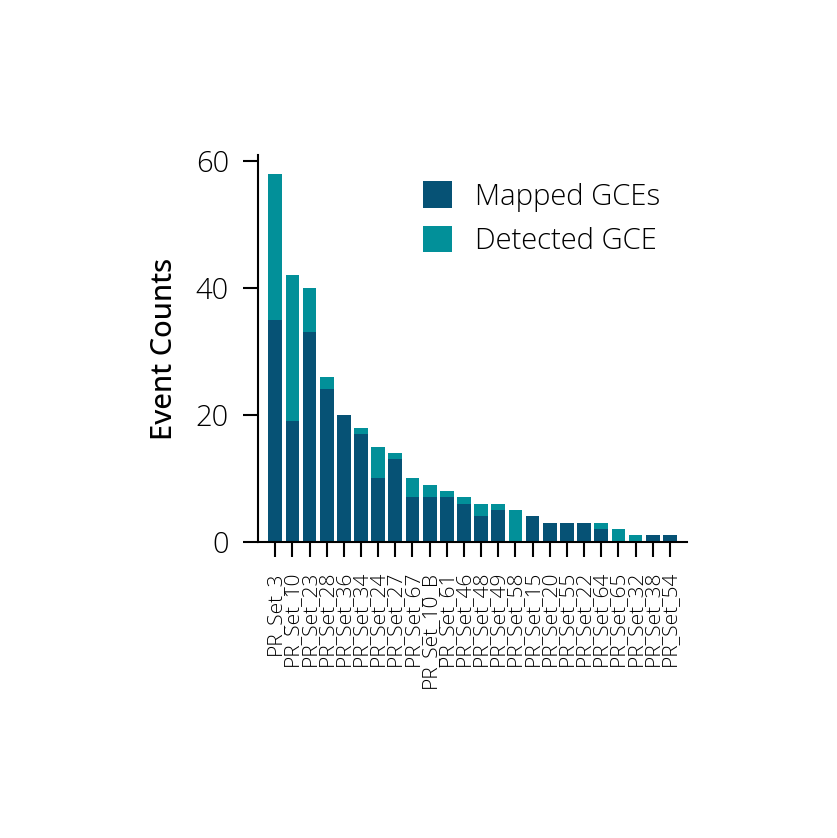

In [569]:
import matplotlib.pyplot as plt
PN_GCE_Stats_WiAnyGCE_df


PN_GCE_Stats_WiAnyGCE_V2_df = PN_GCE_Stats_WiAnyGCE_df.copy()

PN_GCE_Stats_WiAnyGCE_V2_df.index = PN_GCE_Stats_WiAnyGCE_V2_df["PR_SetID"].values

PN_WiAnyGCE_set_summary_put = PN_GCE_Stats_WiAnyGCE_V2_df['putative']
PN_WiAnyGCE_set_summary_map = PN_GCE_Stats_WiAnyGCE_V2_df['mapped'].reindex(PN_WiAnyGCE_set_summary_put.index)


# Compute the "extra" putative-only portion
PN_WiAnyGCE_extra_put = PN_WiAnyGCE_set_summary_put - PN_WiAnyGCE_set_summary_map

x = range(len(PN_WiAnyGCE_set_summary_put))

plt.figure(figsize=(2, 2))

# Bottom: mapped GCEs
plt.bar(
    x,
    PN_WiAnyGCE_set_summary_map.values,
    label="Mapped GCEs",
)

# Top: putative-only (stacked on top of mapped)
plt.bar(
    x,
    PN_WiAnyGCE_extra_put.values,
    bottom=PN_WiAnyGCE_set_summary_map.values,
    label="Detected GCE",
)

plt.xlim(-1, len(PN_WiAnyGCE_set_summary_put))

plt.xticks(x, PN_WiAnyGCE_set_summary_put.index, rotation=90, fontsize=5)
plt.xlabel("") # "Paralog Set"
plt.ylabel("Event Counts")
#plt.title("Stacked Barplot: Putative vs Mapped GCEs per Paralog Set")
plt.legend(loc="upper right", fontsize=7)
plt.tight_layout()
sns.despine()

plt.savefig("ParalogNetwork.GCEFreq.Barplot.v1.svg",
            bbox_inches="tight" )

plt.show()


In [570]:
gini_coefficient_FromPDSeries(PN_WiAnyGCE_set_summary_put)

0.5561475409836065

In [571]:
gini_coefficient_FromPDSeries(PN_WiAnyGCE_set_summary_map)

0.5520833333333333

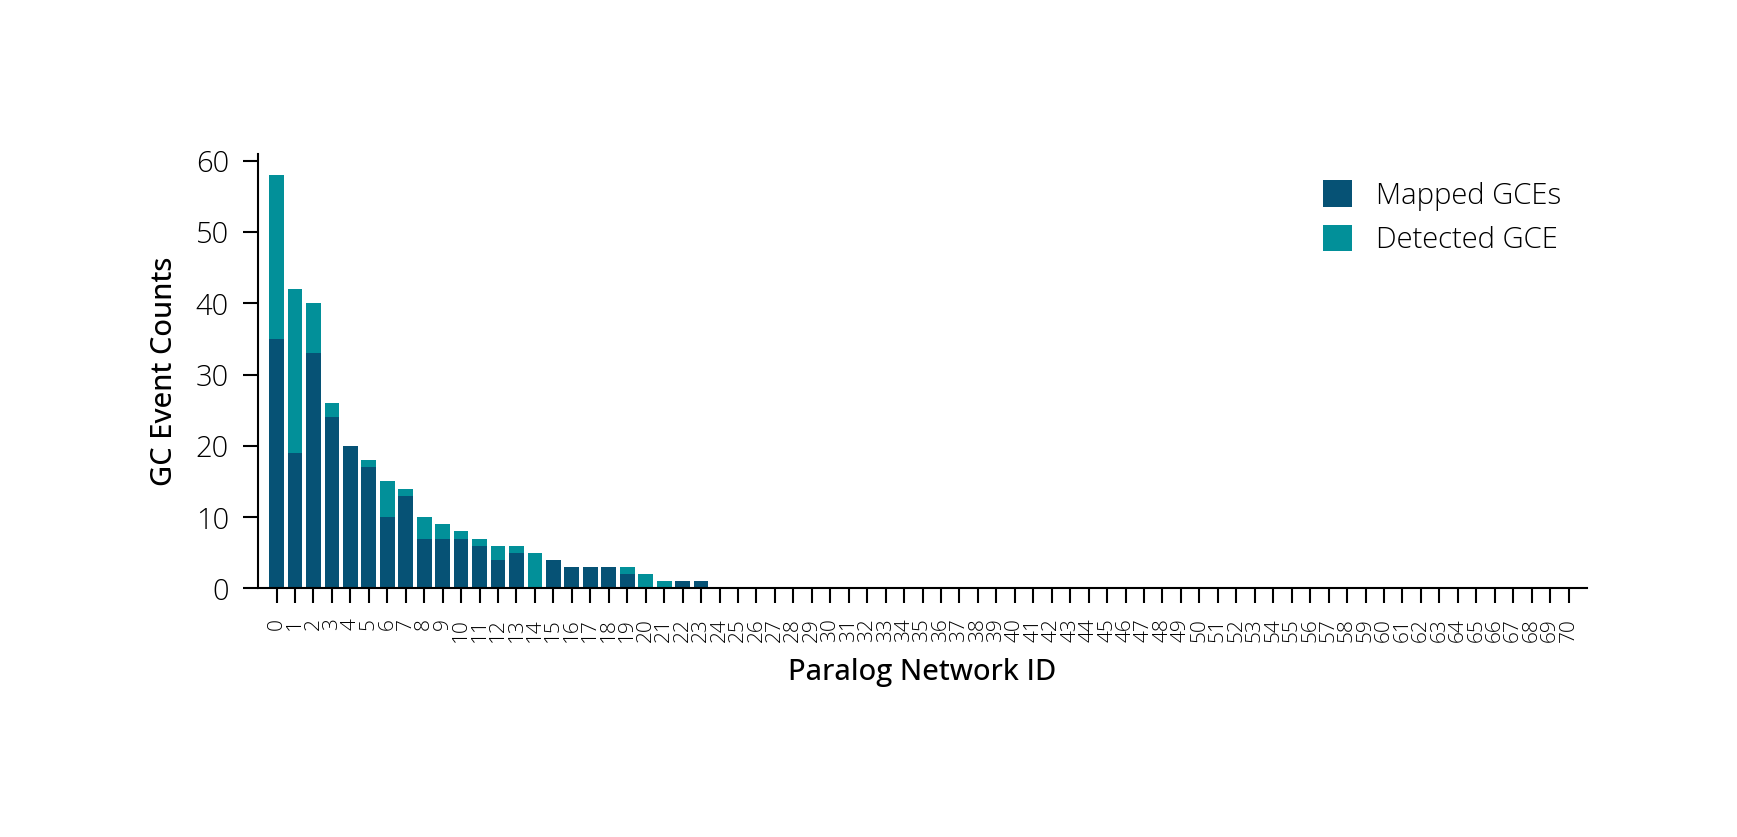

In [572]:
import matplotlib.pyplot as plt

PN_GCE_Stats_V2_df = PN_GCE_Stats_df.copy()
PN_GCE_Stats_V2_df.index = PN_GCE_Stats_V2_df["PR_SetID"].values

PN_All_set_summary_put = PN_GCE_Stats_df['putative']
PN_All_set_summary_map = PN_GCE_Stats_df['mapped'].reindex(PN_All_set_summary_put.index)



# Compute the "extra" putative-only portion
PN_All_extra_put = PN_All_set_summary_put - PN_All_set_summary_map

x = range(len(set_summary_put))

plt.figure(figsize=(5, 2))

# Bottom: mapped GCEs
plt.bar(
    x,
    PN_All_set_summary_map.values,
    label="Mapped GCEs",
)

# Top: putative-only (stacked on top of mapped)
plt.bar(
    x,
    PN_All_extra_put.values,
    bottom=PN_All_set_summary_map.values,
    label="Detected GCE",
)

plt.xlim(-1, len(PN_All_set_summary_put))

plt.xticks(x, PN_All_set_summary_put.index, rotation=90, fontsize=5)
plt.xlabel("Paralog Network ID") # "Paralog Set"
plt.ylabel("GC Event Counts")
#plt.title("Stacked Barplot: Putative vs Mapped GCEs per Paralog Set")
plt.legend(loc="upper right", fontsize=7)
plt.tight_layout()
sns.despine()
plt.show()


In [573]:
gini_coefficient_FromPDSeries(PN_All_set_summary_put)

0.8499653659662896

In [574]:
gini_coefficient_FromPDSeries(PN_All_set_summary_map)

0.8485915492957747

# Part Y: Create`H37Rv` Paralog Network Graphs - Using mod PN10 version

In [575]:
PR_RegionNum_To_Genes_Dict = dict(HmRegions_DonorAndEventCt_ModPN10_DF[['HmRegion_Num', 'Overlap_Genes']].values)

In [576]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [577]:
HmRegions_DonorAndEventCt_ModPN10_DF.shape

(202, 24)

### Create graph object (uni-directional) of ALL Hm-Pairs

In [578]:
# PR_UniGraph_ALL = CreatePR_UGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
#                                   HmPair_EventCt_ModPN10_DF,
#                                   edge_keep_mode = 'keep_all')


### Create graph object (uni-directional) of putative EVENT COUNTs between Hm-Pairs

In [579]:
PR_UniGraph_pGCE_Only = CreatePR_UGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                  HmPair_EventCt_ModPN10_DF,
                                  edge_keep_mode = 'keep_edges_Any_GCE')


In [580]:
pGCE_UniGraph_Stats_Dict, pGCE_UniGraph_Stats_DF = summarize_graph_stats(PR_UniGraph_pGCE_Only)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {pGCE_UniGraph_Stats_Dict[k]}")
    

num_nodes: 70
num_edges: 63
num_connected_components: 25


### Create graph object (bi-directional) of ALL Hm-Pairs

In [581]:
# PR_DiGraph_ALL = CreatePR_DiGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
#                                          HmPair_EventCt_ModPN10_DF,
#                                          edge_keep_mode = 'keep_all')


### Create graph object (bi-directional) of putative EVENT COUNTs between Hm-Pairs

In [582]:
PR_DiGraph_pGCE_Only = CreatePR_DiGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                                  HmPair_EventCt_ModPN10_DF,
                                                  edge_keep_mode = 'keep_edges_Any_GCE')


In [583]:
pGCE_DiGraph_Stats_Dict, pGCE_DiGraph_Stats_DF = summarize_graph_stats(PR_DiGraph_pGCE_Only)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {pGCE_DiGraph_Stats_Dict[k]}")
    

num_nodes: 70
num_edges: 98
num_connected_components: 25


# Generate Paralog-Map Graph Visualizations (Non-directed)

In [584]:
!mkdir MappedEvents_GraphFiles/

mkdir: cannot create directory ‘MappedEvents_GraphFiles/’: File exists


## Viz pGCE RPS Network

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


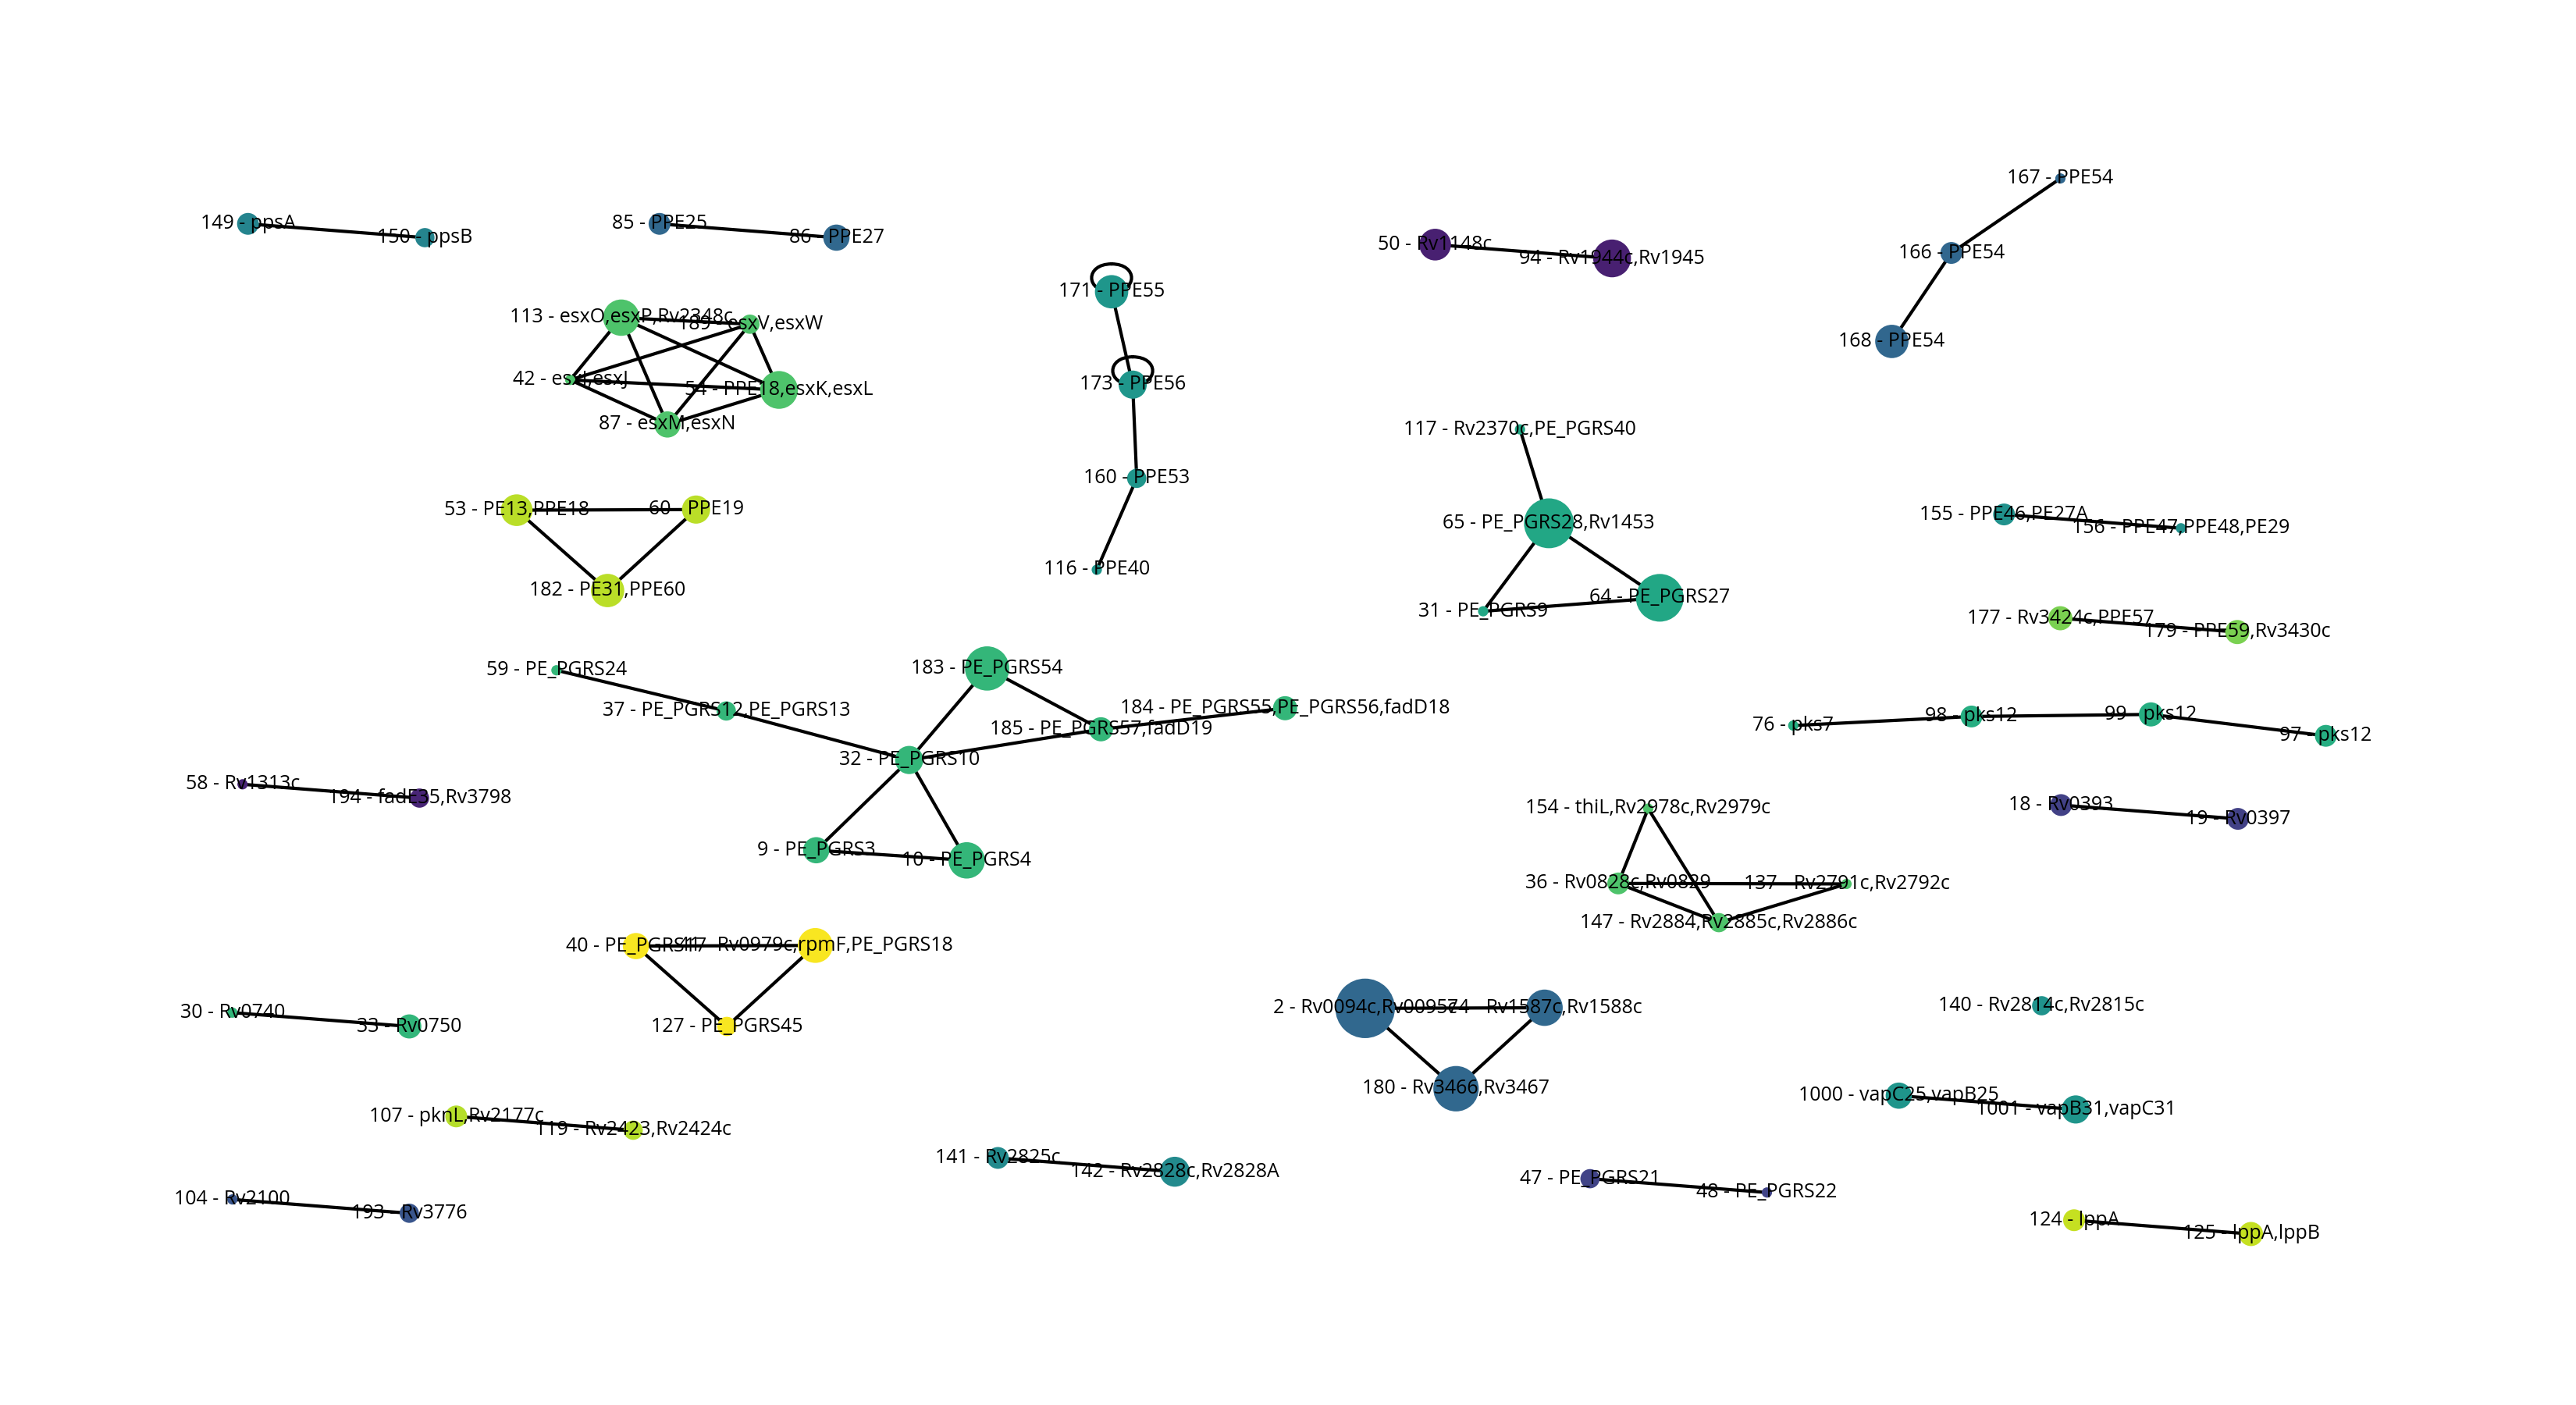

In [585]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = PR_UniGraph_pGCE_Only
#in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )

#plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.V1.svg")
plt.show()


## Viz pGCE RPS Network - w/ Paralog Network Label

/tmp/ipykernel_2790052/2025714388.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.WiGCE.WiNetworkLabels.NX.V1.svg")


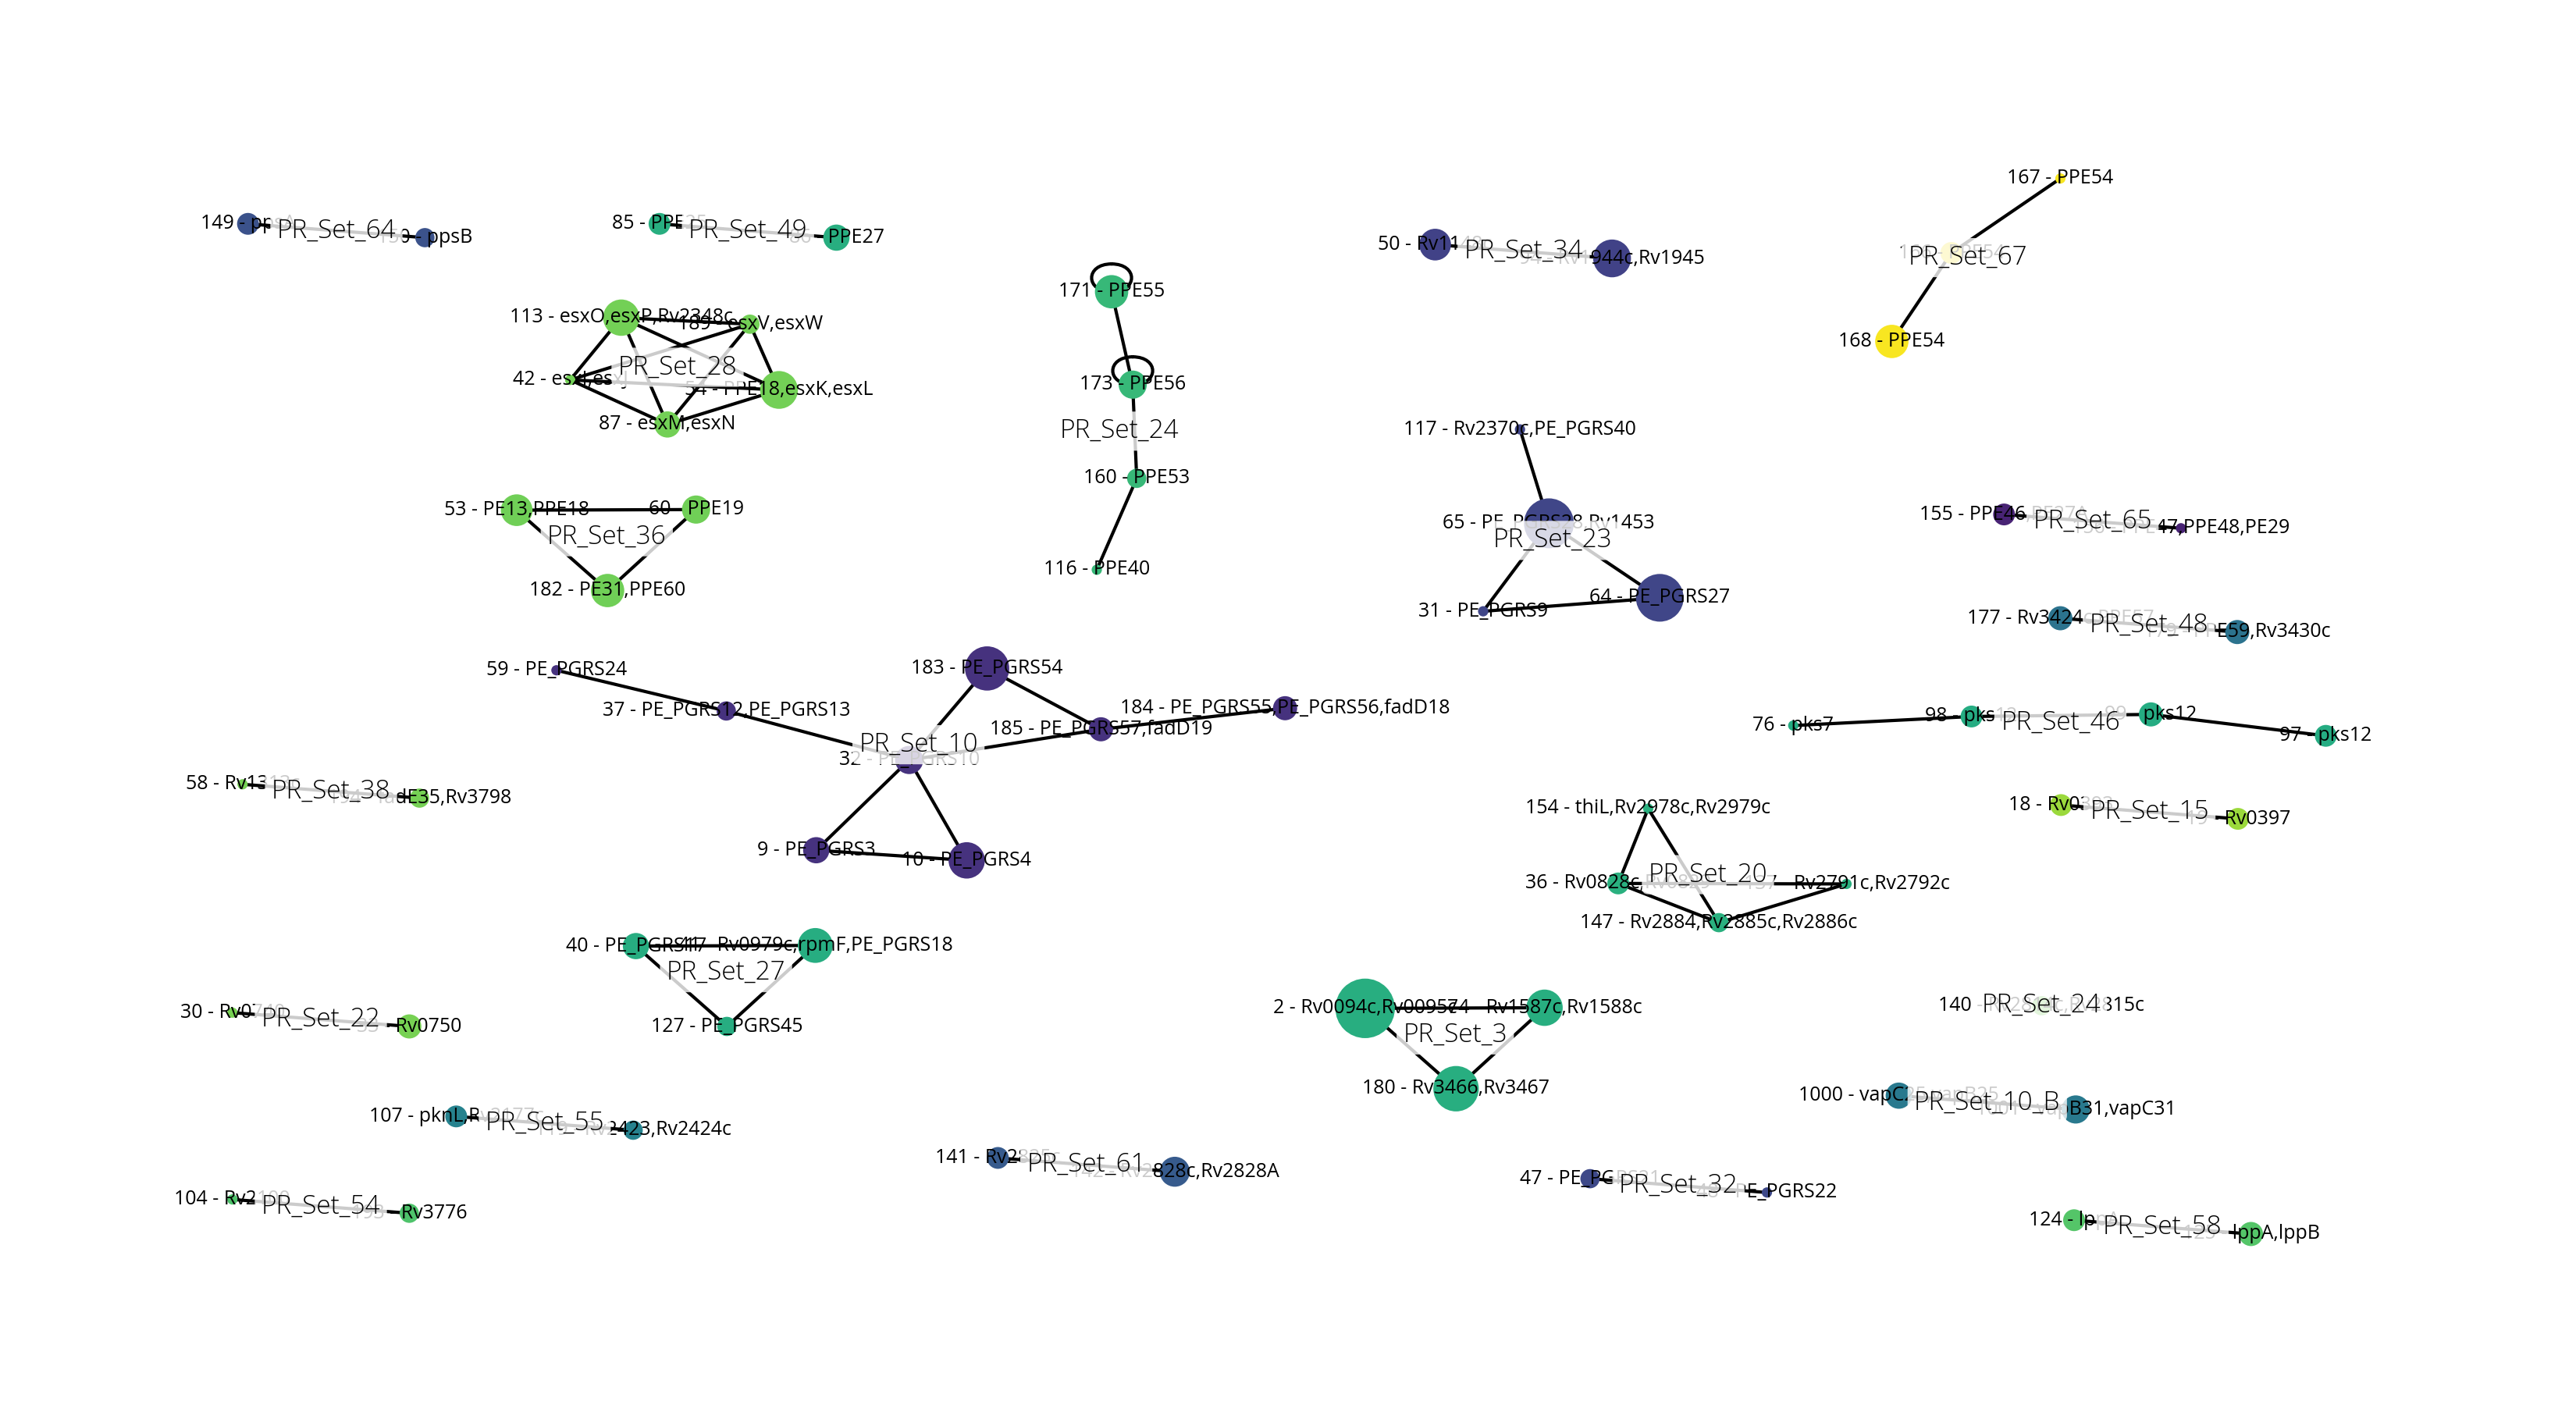

In [586]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = PR_UniGraph_pGCE_Only
#in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )


    # ---------- Add PR_SetID label per component ----------
    # Collect PR_SetID values for nodes in this component
    pr_ids = {
        in_Paralog_Graph.nodes[n].get("PR_SetID")
        for n in g.nodes()
    }
    # Expecting exactly one, but fall back if not
    if len(pr_ids) == 1:
        comp_label = next(iter(pr_ids))
    else:
        # e.g. if missing or mixed, just show all or use a generic label
        comp_label = ", ".join(sorted(str(x) for x in pr_ids if x is not None)) or "Unlabeled"

    # Compute centroid of node positions in this component
    xs = [pos[n][0] for n in g.nodes()]
    ys = [pos[n][1] for n in g.nodes()]
    x_center = np.mean(xs)
    y_center = np.mean(ys)

    # Draw the label at the centroid
    plt.text(
        x_center, y_center,
        comp_label,
        ha="center", va="center",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.25",
                  fc="white", ec="none", alpha=0.8)
    )


plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.WiGCE.WiNetworkLabels.NX.V1.svg")
plt.show()


# Part X: Define updated paralog network functions

In [587]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def graphviz_layout_safe(H, prog="neato", args='-Glen=0.2', seed=0):
    """Graphviz layout with spring_layout fallback."""
    try:
        return nx.nx_agraph.graphviz_layout(H, prog=prog, args=args)
    except Exception:
        return nx.spring_layout(H, seed=seed)

def node_size_dict(G, attr="counts_pGCE", base=25.0, scale=10.0, min_size=10.0):
    out = {}
    for n in G.nodes():
        n_pGCE_ForNode = G.nodes[n].get(attr, 0.0)
        
        #print(n, n_pGCE_ForNode)
        if n_pGCE_ForNode == 0:
            node_size = min_size 
        else:
            node_size = base + (scale * n_pGCE_ForNode)
        
        out[n] = node_size  # (min_size + 10 * n_pGCE_ForNode) if v > 0 else min_size
    return out

def build_node_labels(G, nodes, add_pGCE_to_label=False, pGCE_attr="counts_pGCE"):
    labels = {}
    for n in nodes:
        if add_pGCE_to_label:
            v = G.nodes[n].get(pGCE_attr, 0.0)
            try:
                v = float(v)
            except Exception:
                v = 0.0
            labels[n] = f"{n}\n(pGCE={v:g})"
        else:
            labels[n] = str(n)
    return labels

def get_nodes_for_pr_setid(G, pr_setid):
    """All nodes whose PR_SetID attribute equals pr_setid."""
    return [n for n, a in G.nodes(data=True) if a.get("PR_SetID") == pr_setid]

def pick_component_for_pr_setid(G, pr_setid, on_multiple="largest"):
    """
    In the ideal case, a PR_SetID corresponds to exactly one connected component.
    If multiple exist, this picks the largest (default) or raises.
    """
    nodes = get_nodes_for_pr_setid(G, pr_setid)
    if not nodes:
        return []

    H = G.subgraph(nodes)
    comps = list(nx.connected_components(H))

    if len(comps) == 1:
        return list(comps[0])

    if on_multiple == "error":
        raise ValueError(f"PR_SetID {pr_setid!r} spans {len(comps)} components. (Expected 1)")

    # default: pick largest
    comps.sort(key=len, reverse=True)
    return list(comps[0])

def plot_packed_components_grid(
    G,
    pr_setid_order,
    pr_setid_to_color=None,
    cols=6,
    pad=160.0,
    layout_prog="neato",
    layout_args='-Glen=0.2',
    node_size_attr="counts_pGCE",
    show_node_labels=False,
    add_pGCE_to_label=False,
    font_size=6,
    pr_label_offset=(0.0, 25.0),
    pr_label_fontsize=10,
    pr_label_box=True,
    figsize=(16, 10),
    default_node_color="#1f77b4",
    on_multiple_components="largest",  # or "error"
):
    """
    Pack connected components (by PR_SetID) onto a grid in ONE axes.

    Args:
      pr_setid_order: list[str] giving the desired plotting order.
      pr_setid_to_color: dict[str, color] mapping PR_SetID -> node color.
    """
    pr_setid_to_color = pr_setid_to_color or {}

    # Build ordered component list (nodes per component) in the user-provided order
    ordered_components = []
    for i, pr in enumerate(pr_setid_order):
        comp_nodes = pick_component_for_pr_setid(G, pr, on_multiple=on_multiple_components)
        if comp_nodes:
            ordered_components.append((pr, comp_nodes))

    # Precompute node sizes (fast)
    node_sizes = node_size_dict(G, attr=node_size_attr)

    node_to_pGCE_Dict = {
        n: G.nodes[n].get("counts_pGCE", 0.0)
        for n in G.nodes()
    }
    
    # Layout + bbox per component
    comp_layouts = []
    for i, (pr, comp_nodes) in enumerate(ordered_components):
        H = G.subgraph(comp_nodes)
        pos = graphviz_layout_safe(H, prog=layout_prog, args=layout_args, seed=i)

        xs = np.array([pos[n][0] for n in H.nodes()], dtype=float)
        ys = np.array([pos[n][1] for n in H.nodes()], dtype=float)
        xmin, xmax = xs.min(), xs.max()
        ymin, ymax = ys.min(), ys.max()
        w, h = (xmax - xmin), (ymax - ymin)

        comp_layouts.append((pr, comp_nodes, pos, xmin, ymin, w, h))

    # Pack onto grid
    final_pos = {}
    comp_bbox = {}  # pr -> (x0,x1,y0,y1) after packing

    x_cursor, y_cursor = 0.0, 0.0
    row_h = 0.0
    col_i = 0

    for pr, comp_nodes, pos, xmin, ymin, w, h in comp_layouts:
        if col_i >= cols:
            col_i = 0
            x_cursor = 0.0
            y_cursor += row_h + pad
            row_h = 0.0

        dx, dy = x_cursor - xmin, y_cursor - ymin
        for n in comp_nodes:
            final_pos[n] = (pos[n][0] + dx, pos[n][1] + dy)

        comp_bbox[pr] = (x_cursor, x_cursor + w, y_cursor, y_cursor + h)

        x_cursor += w + pad
        row_h = max(row_h, h)
        col_i += 1

    # Build node colors ONLY for nodes we’re plotting
    nodes_to_draw = [n for _, comp_nodes in ordered_components for n in comp_nodes]
    node_color_map = {}
    for pr, comp_nodes in ordered_components:
        c = pr_setid_to_color.get(pr, default_node_color)
        for n in comp_nodes:
            node_color_map[n] = c
    node_colors = [node_color_map[n] for n in nodes_to_draw]

    # Labels (optional)
    labels = build_node_labels(G, nodes_to_draw, add_pGCE_to_label=add_pGCE_to_label) if show_node_labels else None

    # Draw
    fig = plt.figure(figsize=figsize)
    ax = plt.gca()

    subgraph_OfNodesToDraw = G.subgraph(nodes_to_draw)
    nx.draw_networkx(
        subgraph_OfNodesToDraw,
        pos=final_pos,
        ax=ax,
        with_labels=show_node_labels,
        labels=labels,
        font_size=font_size,
        node_size=[node_sizes[n] for n in subgraph_OfNodesToDraw.nodes()],
        node_color=node_colors,
        linewidths=0.3,
        width=0.4,
    )

    # print("Drawing the following nodes:")
    # for n in nodes_to_draw:
    #     print("node:", n, "size:", node_sizes[n], "N_pGCE", node_to_pGCE_Dict.get(n, 0) )
        

    
    # PR_SetID labels
    for pr, (x0, x1, y0, y1) in comp_bbox.items():
        ax.text(
            x0 + pr_label_offset[0],
            y1 + pr_label_offset[1],
            pr,
            fontsize=pr_label_fontsize,
            ha="left", va="bottom",
            bbox=(dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8) if pr_label_box else None),
        )

    ax.axis("off")
    ax.invert_yaxis()
    plt.tight_layout()
    return fig, ax


# Try 4 

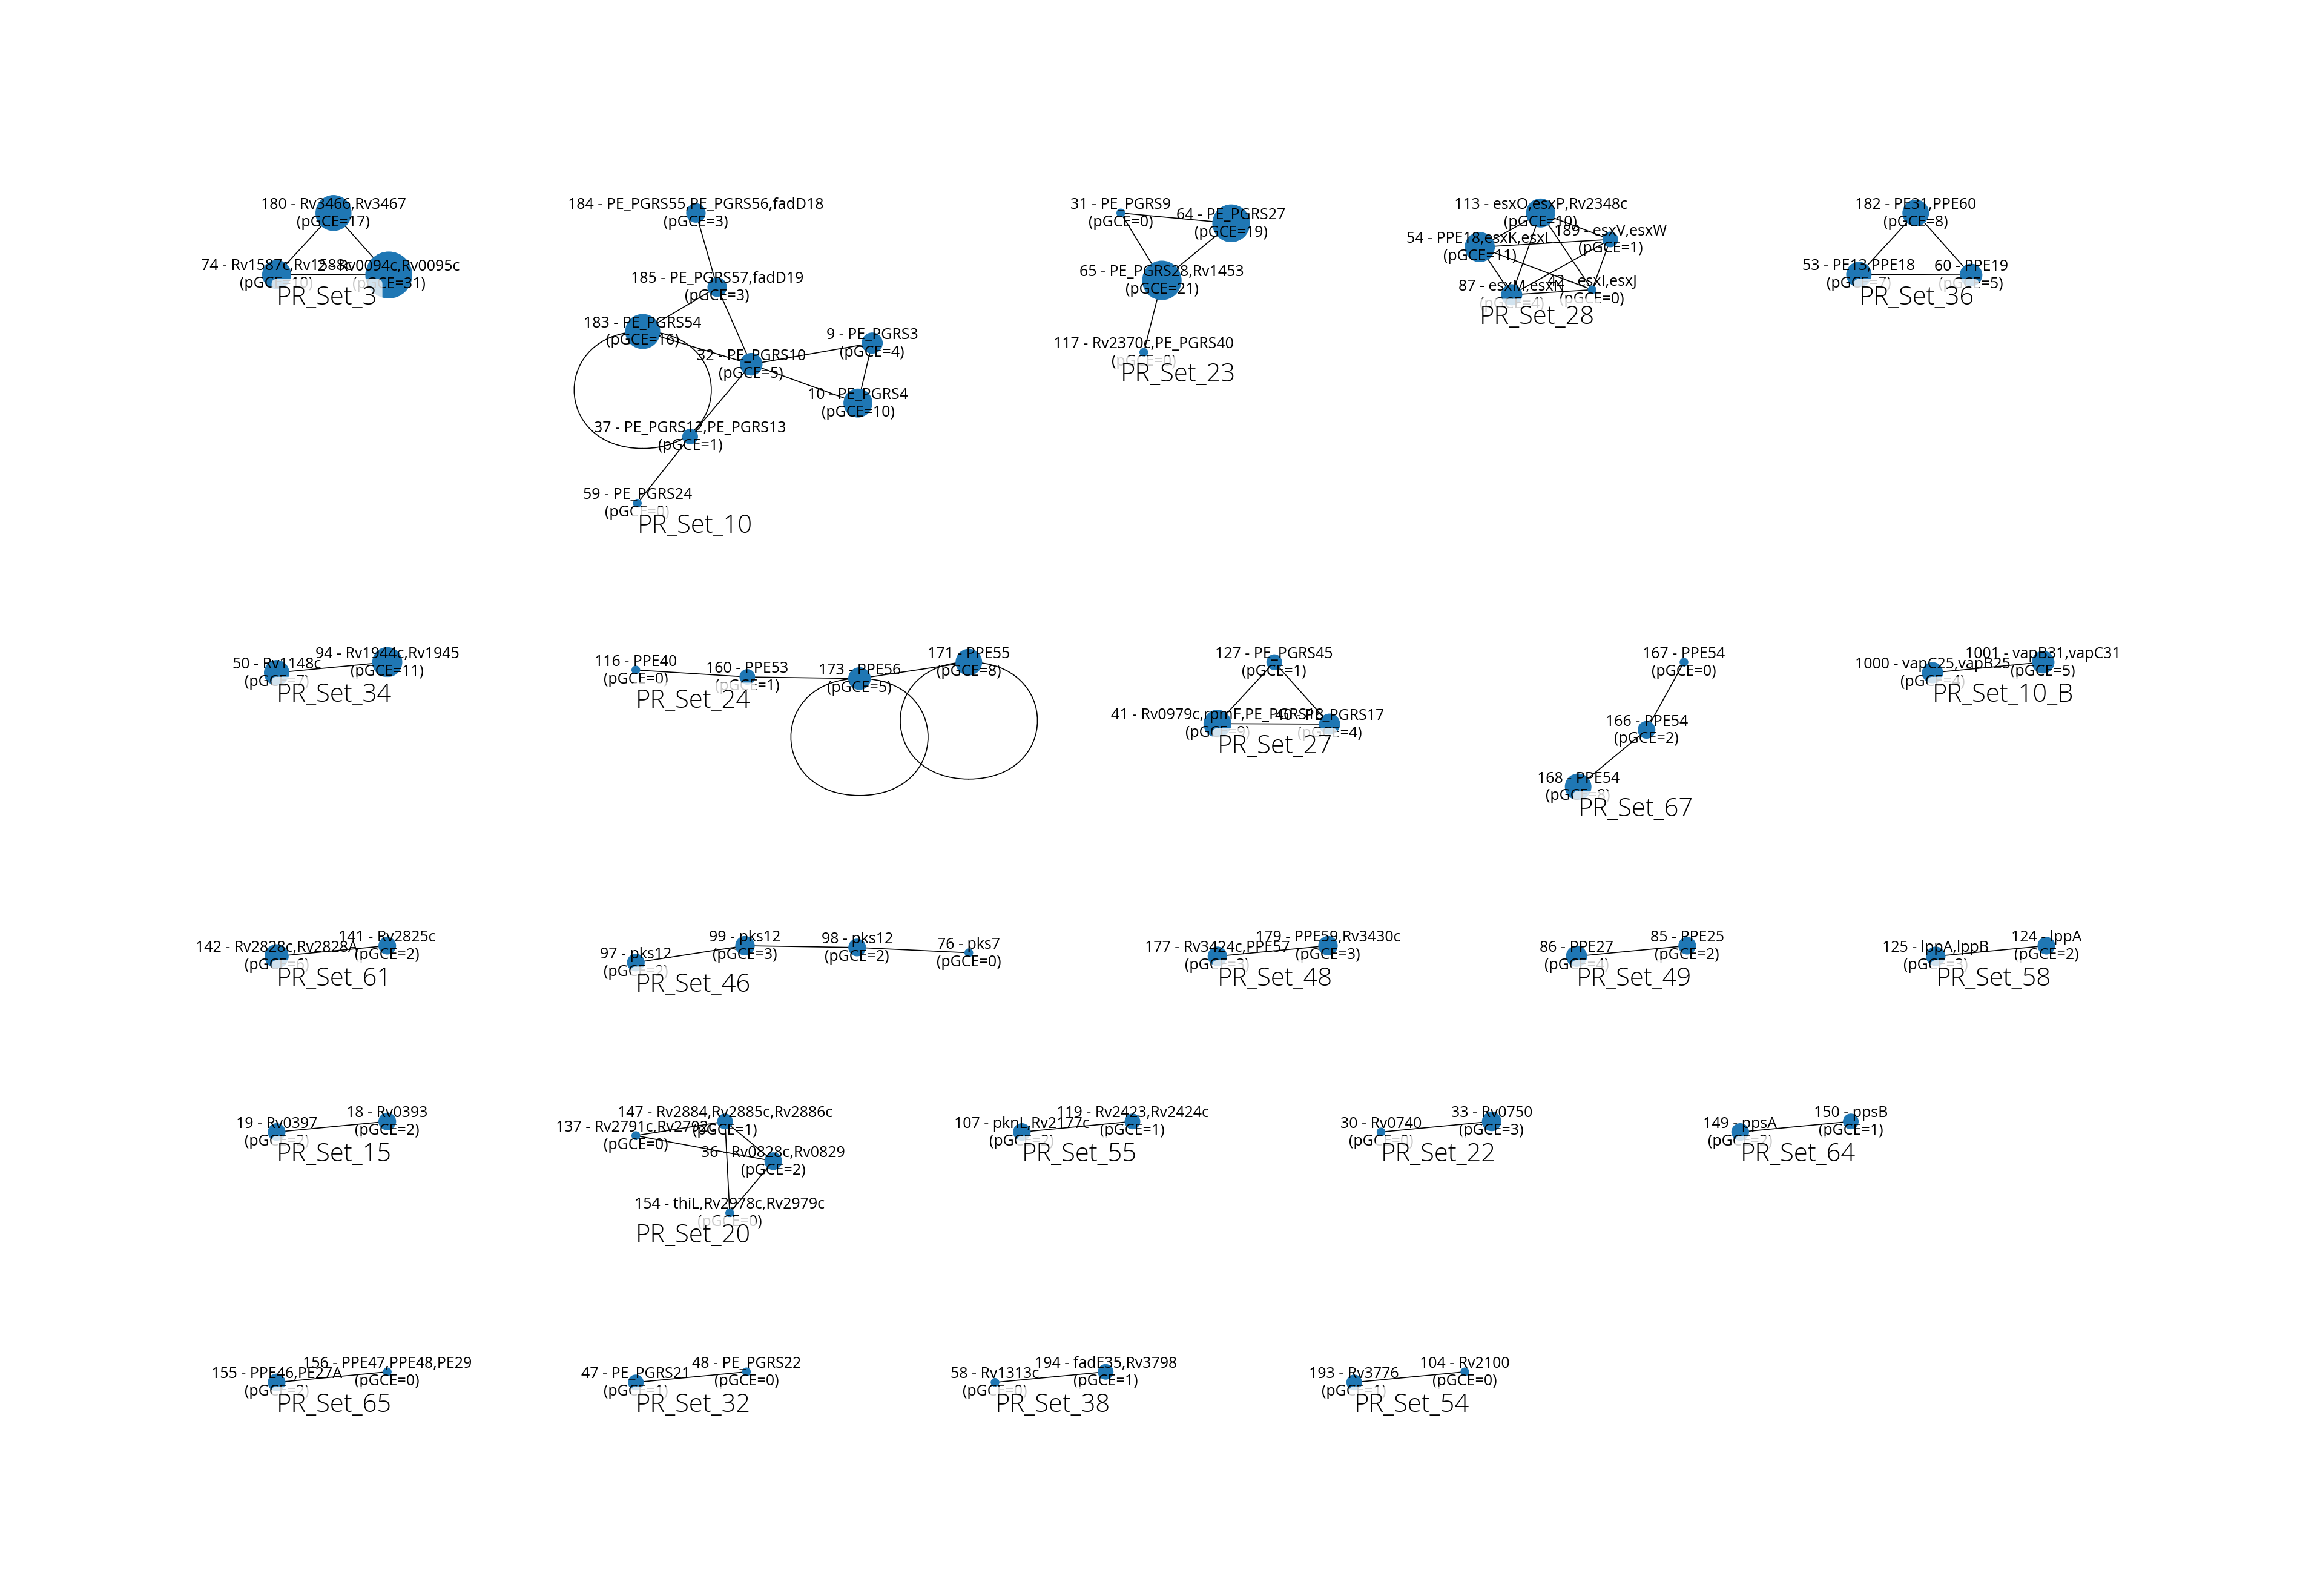

In [588]:
fig, ax = plot_packed_components_grid(
    PR_UniGraph_pGCE_Only,
    pr_setid_order = list(set_summary_put.index),
    #pr_setid_to_color=pr_setid_to_color,
    cols=5,
    pad=160,
    show_node_labels=True,
    add_pGCE_to_label=True,
    pr_label_offset = (0,35),
    figsize=(12, 8),
)
plt.savefig("MappedEvents_GraphFiles/GCE.ParalogNetworks.Sorted.Labeled.V1.svg")
plt.show()

In [589]:
Top5_PN_Only_SubG = subset_graph_by_PR_SetIDs(PR_UniGraph_pGCE_Only, ["PR_Set_3", "PR_Set_10", "PR_Set_23", "PR_Set_28", "PR_Set_36"])
summarize_graph_stats(Top5_PN_Only_SubG)


({'num_nodes': 23,
  'num_edges': 30,
  'is_directed': False,
  'num_connected_components': 5,
  'connected_component_sizes': [8, 5, 4, 3, 3],
  'degree_min': 1.0,
  'degree_max': 5.0,
  'degree_mean': 2.608695652173913,
  'degree_median': 2.0,
  'edge_weight_min': 0.0,
  'edge_weight_max': 33.0,
  'edge_weight_mean': 4.233333333333333,
  'edge_weight_median': 1.5},
   ComponentID  NumNodes
 0      Comp_1         8
 1      Comp_2         5
 2      Comp_3         4
 3      Comp_4         3
 4      Comp_5         3)

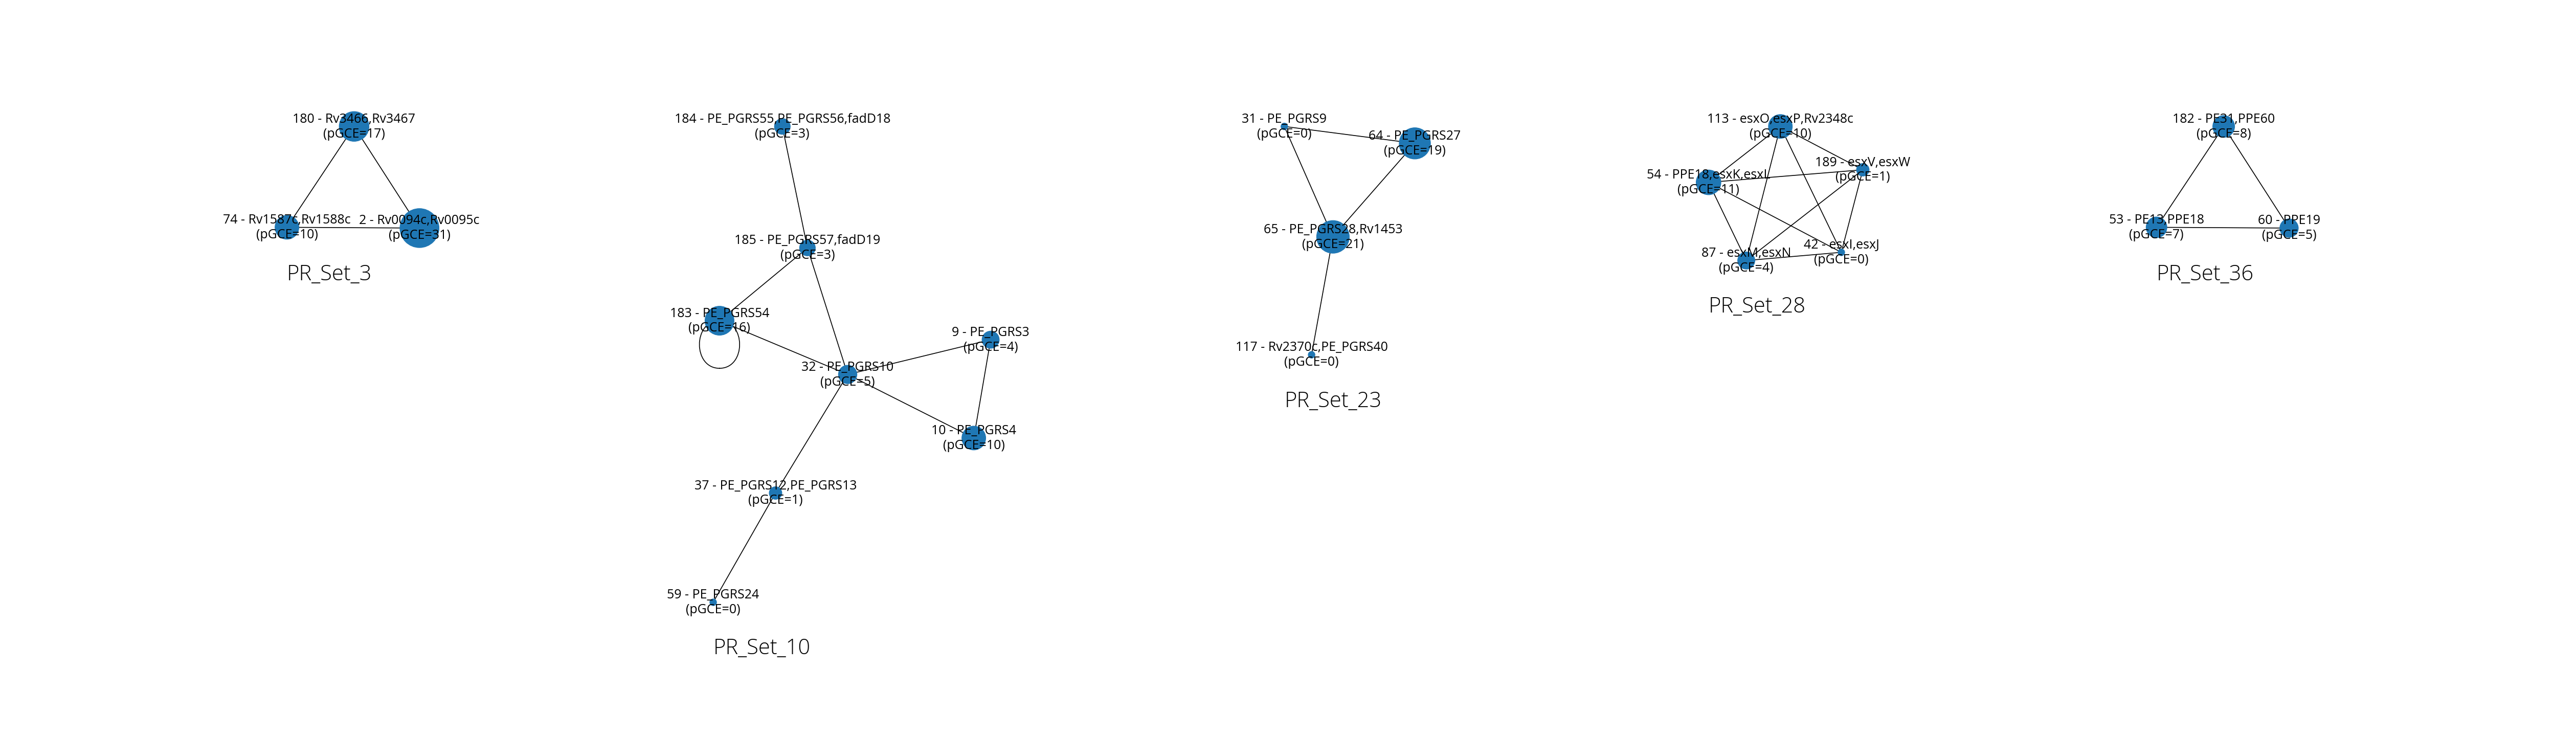

In [590]:
fig, ax = plot_packed_components_grid(
    Top5_PN_Only_SubG,
    pr_setid_order = list(set_summary_put.index),
    #pr_setid_to_color=pr_setid_to_color,
    cols=5,
    pad=160,
    show_node_labels=True,
    add_pGCE_to_label=True,
    pr_label_offset = (0,35),
    figsize=(16, 4),
)
plt.show()

In [611]:
# Test_NodeSize_dict = node_size_dict(Top5_PN_Only_SubG)


In [609]:
#Test_NodeSize_dict

# Explore dominant gene category per Paralog Network

In [593]:
PerPR_GCE_SummStats_long_df.head()

,PR_SetID,HmRegionID,Overlap_Genes,putative_set_total,mapped_set_total,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,PR_HmRegion_002,"Rv0094c,Rv0095c",58.0,35.0,[REP13E12_Repeat],1
1,PR_Set_3,PR_HmRegion_074,"Rv1587c,Rv1588c",58.0,35.0,[REP13E12_Repeat],1
2,PR_Set_3,PR_HmRegion_180,"Rv3466,Rv3467",58.0,35.0,[REP13E12_Repeat],1
3,PR_Set_10,PR_HmRegion_009,PE_PGRS3,42.0,19.0,[PE/PPE],1
4,PR_Set_10,PR_HmRegion_010,PE_PGRS4,42.0,19.0,[PE/PPE],1


In [594]:
PN_GCE_Stats_df.head(3)

,PR_SetID,putative,mapped,num_regions,num_genes,genes,genes_csv,region_gene_map,num_region_gene_map_entries,Gene_Categories,Num_Gene_Categories
0,PR_Set_3,58.0,35.0,3,6,"[Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, R...","Rv0094c, Rv0095c, Rv1587c, Rv1588c, Rv3466, Rv...","{'PR_HmRegion_002': 'Rv0094c,Rv0095c', 'PR_HmR...",3,[REP13E12_Repeat],1
1,PR_Set_10,42.0,19.0,9,13,"[PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, P...","PE_PGRS10, PE_PGRS12, PE_PGRS13, PE_PGRS24, PE...","{'PR_HmRegion_009': 'PE_PGRS3', 'PR_HmRegion_0...",9,"[PE/PPE, lipid metabolism]",2
2,PR_Set_23,40.0,33.0,4,6,"[PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv...","PE_PGRS27, PE_PGRS28, PE_PGRS40, PE_PGRS9, Rv1...","{'PR_HmRegion_031': 'PE_PGRS9', 'PR_HmRegion_0...",4,"[PE/PPE, conserved hypotheticals, regulatory p...",3


In [ ]:
ParalogNetwork_To_PriGeneCat =  { "PR_Set_3" : "REP13E12_Repeat",
                                  "PR_Set_10" : "PE/PPE",
                                  "PR_Set_23" : "PE/PPE",
                                  "PR_Set_28" : "esx",
                                  "PR_Set_36" : "PE/PPE",
                                  "PR_Set_34" : "REP13E12_Repeat",
                                  "PR_Set_24" : "PE/PPE",
                                  "PR_Set_27" : "PE/PPE",
                                  "PR_Set_67" : "PE/PPE",
                                  "PR_Set_10_B" : "virulence, detoxification, adaptation",
                                  "PR_Set_61" : "conserved hypotheticals",
                                  "PR_Set_46" : "lipid metabolism",
                                  "PR_Set_48" : "PE/PPE",
                                  "PR_Set_49" : "PE/PPE",
                                  "PR_Set_58" : "cell wall and cell processes",
                                  "PR_Set_15" : "REP13E12_Repeat",
                                  "PR_Set_20" : "insertion seqs and phages", # Unclear, have to check
                                  "PR_Set_55" : "insertion seqs and phages", # Unclear, have to check
                                  "PR_Set_22" : "conserved hypotheticals",
                                  "PR_Set_64" : "lipid metabolism",
                                  "PR_Set_65" : 'PE/PPE',
                                  "PR_Set_32" : 'PE/PPE',
                                  "PR_Set_38" : "insertion seqs and phages", # Unclear, have to check
                                  "PR_Set_54" : "REP13E12_Repeat",
                                  }

In [605]:
PN_GCE_Stats_WiAnyGCE_df.tail(10)[["PR_SetID", "putative", "genes", "Gene_Categories"]].values

array([['PR_Set_58', 5.0, list(['lppA', 'lppB']),
        list(['cell wall and cell processes'])],
       ['PR_Set_15', 4.0, list(['Rv0393', 'Rv0397']),
        list(['REP13E12_Repeat'])],
       ['PR_Set_20', 3.0,
        list(['Rv0605', 'Rv0606', 'Rv0828c', 'Rv0829', 'Rv2791c', 'Rv2792c', 'Rv2884', 'Rv2885c', 'Rv2886c', 'Rv2978c', 'Rv2979c', 'Rv3827c', 'Rv3828c', 'Rv3829c', 'fadD23', 'thiL']),
        list(['insertion seqs and phages', 'intermediary metabolism and respiration', 'lipid metabolism', 'regulatory proteins'])],
       ['PR_Set_55', 3.0, list(['Rv2177c', 'Rv2423', 'Rv2424c', 'pknL']),
        list(['conserved hypotheticals', 'insertion seqs and phages', 'regulatory proteins'])],
       ['PR_Set_22', 3.0, list(['Rv0740', 'Rv0750']),
        list(['conserved hypotheticals'])],
       ['PR_Set_64', 3.0, list(['ppsA', 'ppsB']),
        list(['lipid metabolism'])],
       ['PR_Set_65', 2.0,
        list(['PE27A', 'PE29', 'PPE46', 'PPE47', 'PPE48']),
        list(['PE/PPE'])],
 

In [608]:
# 

HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_38'")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
60,58,NC_000962.3,1468141,1469654,1468897.5,1513,Rv1313c,1,1,1,1,58,PR_HmRegion_058,0,PR_Set_38,1.0,0,0,-1.0,1.0,-1.0,0.0,5,5
196,194,NC_000962.3,4252853,4254367,4253610.0,1514,"fadE35,Rv3798",1,1,1,1,194,PR_HmRegion_194,0,PR_Set_38,0.0,1,1,1.0,1.0,1.0,1.0,5,5


In [607]:
# PR_Set_55 seems to invole transposases undergoing gene conversion
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_55'")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
109,107,NC_000962.3,2439139,2439948,2439543.5,809,"pknL,Rv2177c",1,1,1,1,107,PR_HmRegion_107,0,PR_Set_55,1.0,2,2,1.0,3.0,0.333333,1.0,13,13
121,119,NC_000962.3,2720634,2721442,2721038.0,808,"Rv2423,Rv2424c",1,1,1,1,119,PR_HmRegion_119,0,PR_Set_55,2.0,1,1,-1.0,3.0,-0.333333,1.0,13,13


In [606]:
# PR_Set_20 seems to invole transposases undergoing gene conversion

#Specifically, Rv0828c,Rv0829 and Rv2884,Rv2885c,Rv2886c	 
HmRegions_DonorAndEventCt_ModPN10_DF.query("PR_SetID == 'PR_Set_20'")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
29,28,NC_000962.3,701363,702728,702045.5,1365,"Rv0605,Rv0606",1,1,1,1,28,PR_HmRegion_028,0,PR_Set_20,0.0,0,0,0.0,0.0,0.000000,0.0,229,229
38,36,NC_000962.3,921579,921893,921736.0,314,"Rv0828c,Rv0829",1,3,3,3,36,PR_HmRegion_036,0,PR_Set_20,0.0,2,2,2.0,2.0,1.000000,1.0,62,46
139,137,NC_000962.3,3100173,3102233,3101203.0,2060,"Rv2791c,Rv2792c",1,5,5,5,137,PR_HmRegion_137,0,PR_Set_20,0.0,0,0,0.0,0.0,0.000000,0.0,1233,806
149,147,NC_000962.3,3194137,3196202,3195169.5,2065,"Rv2884,Rv2885c,Rv2886c",1,3,3,3,147,PR_HmRegion_147,0,PR_Set_20,2.0,1,1,-1.0,3.0,-0.333333,1.0,781,582
156,154,NC_000962.3,3333757,3335814,3334785.5,2057,"thiL,Rv2978c,Rv2979c",1,4,4,4,154,PR_HmRegion_154,0,PR_Set_20,1.0,0,0,-1.0,1.0,-1.000000,0.0,1087,723
198,196,NC_000962.3,4301541,4303432,4302486.5,1891,"fadD23,Rv3827c,Rv3828c,Rv3829c",1,2,2,2,196,PR_HmRegion_196,0,PR_Set_20,0.0,0,0,0.0,0.0,0.000000,0.0,620,495


In [178]:
ManDict_PN_setid_to_color = { "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                              "__" : "__",
                            }


# Extras

### Make a reference set of node sizes

/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


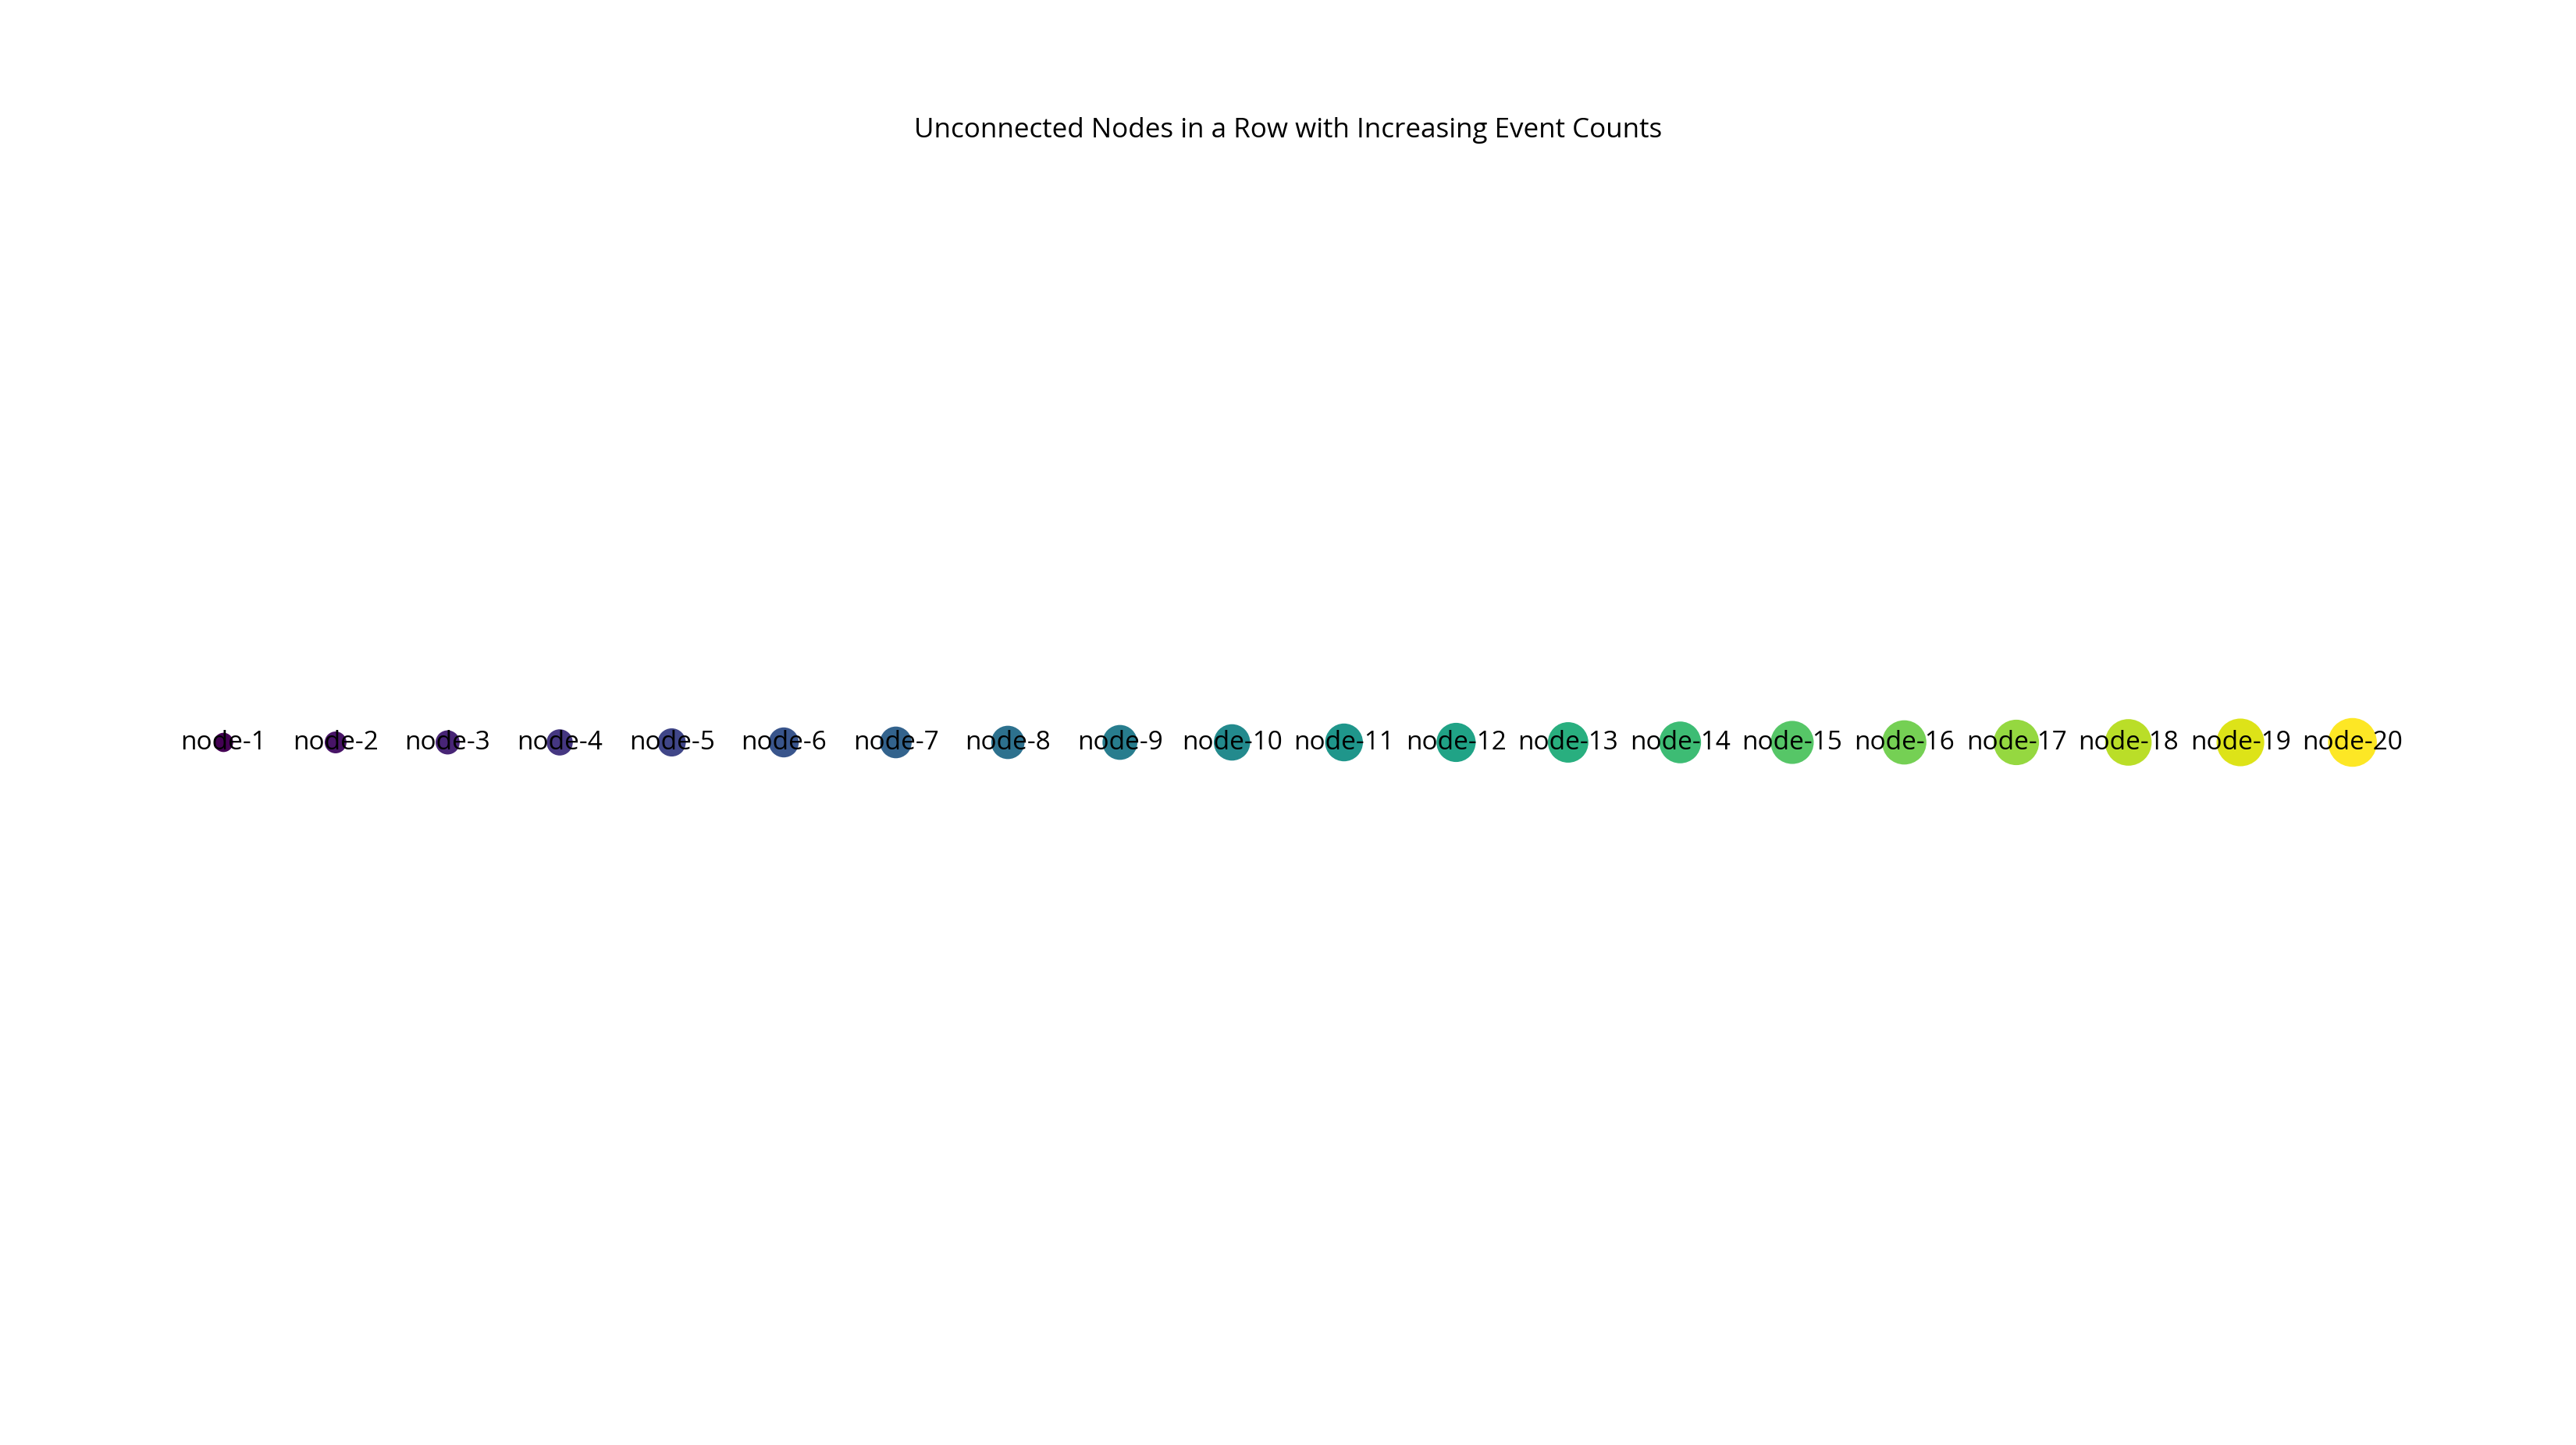

In [173]:
import numpy as np

# Create an empty graph
RefSizes_G = nx.Graph()

# Number of nodes to add
num_nodes = 20

# Add unconnected nodes with increasing eventcounts

pos = {}

for i in range(1, num_nodes + 1):
    CT = i
    node_name = f"node-{i}"
    
    pos[node_name] = (i, 0)
    
    RefSizes_G.add_node(node_name, counts_mGCE=i)

# Extract event counts for node sizes
event_counts = nx.get_node_attributes(RefSizes_G, "counts_mGCE")
node_sizes = [25 + (v * 10) for v in event_counts.values()]  # Scale by event counts

node_sizes = [25 + (v * 10) if v > 0 else 30 for v in event_counts.values()]

# Arrange nodes in a row from left to right
pos = {f"node-{i}": (i, 0) for i in range(1, num_nodes + 1)}

# Plot the graph
plt.figure(1, figsize=(10, 5))
nx.draw(RefSizes_G, pos, 
    node_size=node_sizes, 
    node_color=list(event_counts.values()),  # Color by eventcounts
    cmap=plt.cm.viridis,
    with_labels=True, 
    font_size=8)

plt.title("Unconnected Nodes in a Row with Increasing Event Counts")
plt.show()


```
{ "PR_Set_3" : "REP13E12_Repeat",
  "PR_Set_10" : "PE/PPE",
  "PR_Set_23" : "PE/PPE",
  "PR_Set_28" : "esx",
  "PR_Set_36" : "PE/PPE",
  "PR_Set_34" : "REP13E12_Repeat",
  "PR_Set_24" : "PE/PPE",
  "PR_Set_27" : "PE/PPE",
  "PR_Set_67" : "PE/PPE",
  "PR_Set_10_B" : "virulence, detoxification, adaptation",
  "PR_Set_61" : "conserved hypotheticals",
  "PR_Set_46" : "lipid metabolism",
  "PR_Set_48" : "PE/PPE",
  "PR_Set_49" : "PE/PPE",
  "PR_Set_58" : "cell wall and cell processes",
  "PR_Set_15" : "REP13E12_Repeat",
  "PR_Set_20" : "insertion seqs and phages", # Unclear, have to check
  "PR_Set_55" : "insertion seqs and phages", # Unclear, have to check
  "PR_Set_22" : "conserved hypotheticals",
  "PR_Set_64" : "lipid metabolism",
  "PR_Set_65" : 'PE/PPE',
  "PR_Set_32" : 'PE/PPE',
  "PR_Set_38" : "insertion seqs and phages", # Unclear, have to check
  "PR_Set_54" : "REP13E12_Repeat",
  }

```